## Load data from Google Sheets

In [1]:
# Install necessary libraries
!pip install gspread gspread-dataframe --quiet

In [14]:
import pandas as pd
import gspread
from google.colab import auth
import google.auth

# Authenticate Google Colab to access Google Drive
auth.authenticate_user()

In [15]:
# Get default credentials set up by auth.authenticate_user()
credentials, project_id = google.auth.default()
gc = gspread.Client(auth=credentials) # Authenticate gspread client with default credentials

# Google Sheet URL provided by the user
gs_url = "https://docs.google.com/spreadsheets/d/1FkcJ3dLSA4yQ3kem0qfIwwaF6Wp6kWosLnPTg5VPHyo/edit?gid=728786107#gid=728786107"

# Extract the spreadsheet key from the URL
sheet_id = gs_url.split('/')[-2]

# Open the spreadsheet by ID
spreadsheet = gc.open_by_key(sheet_id)

# Get the worksheet by its gid (728786107 in this case)
# You might need to adjust this if the gid changes or you want a different worksheet
worksheet = spreadsheet.get_worksheet_by_id(728786107)

# Load the data into a pandas DataFrame using gspread's direct method
df = pd.DataFrame(worksheet.get_all_records())

# Display the first 5 rows of the DataFrame
display(df.head())

,Dấu thời gian,Câu 1: Bạn sinh vào năm nào?,Câu 2: Bạn đã từng mua sản phẩm trên TikTok Shop thông qua livestream bán hàng chưa?,"Câu 3: Bạn đang sinh sống, học tập và làm việc tại khu vực Thành phố Hồ Chí Minh.",Câu 4: Tần suất bạn xem livestream bán hàng trên TikTok Shop là bao nhiêu?,"Câu 5: Trung bình trong 1 tháng, bạn mua hàng qua livestream trên TikTok Shop bao nhiêu lần?",Câu 6: Nhóm sản phẩm nào bạn THƯỜNG XUYÊN mua nhất qua livestream TikTok Shop?,"Câu 7: Trong 6 tháng qua, bạn đã thực hiện yêu cầu ""Trả hàng/Hoàn tiền"" trên TikTok Shop bao nhiêu lần đối với các sản phẩm mua qua livestream?",Câu 8: Thông tin về sản phẩm trong livestream rõ ràng và dễ hiểu.,Câu 9: Livestream cung cấp đầy đủ thông tin cần thiết giúp tôi dễ dàng đưa ra quyết định.,...,Câu 50: Tôi sẽ không giới thiệu sản phẩm này cho người khác.,Câu 51: Tôi sẽ khuyên bạn bè và người thân không nên mua sản phẩm này.,Câu 52: Tôi sẽ chia sẻ trải nghiệm tiêu cực của mình về sản phẩm trên mạng xã hội.,Câu 53: Tôi sẽ để lại bình luận tiêu cực về sản phẩm.,Câu 53: Tôi sẽ tẩy chay đối với các bài đăng liên quan đến sản phẩm.,Câu 54: Tôi sẽ chủ động chia sẻ hoặc tìm kiếm thêm các bài viết phản ánh tiêu cực về sản phẩm.,Câu 55: Tôi sẽ chia sẻ các nội dung tiêu cực liên quan đến trải nghiệm mua hàng của mình.,Câu 56: Giới tính của bạn,Câu 57: Tình trạng công việc hiện tại của bạn là,Câu 58: Thu nhập hoặc chi tiêu trung bình hàng tháng của bạn là bao nhiêu?
0,02/07/2026 11:48:43,Từ năm 1997 đến năm 2012,Có,Khu vực khác,,,,,,,...,,,,,,,,,,
1,02/07/2026 11:49:45,Từ năm 1997 đến năm 2012,Chưa,,,,,,,,...,,,,,,,,,,
2,02/07/2026 11:49:47,Từ năm 1997 đến năm 2012,Có,Khu vực khác,,,,,,,...,,,,,,,,,,
3,02/07/2026 11:52:06,Từ năm 1997 đến năm 2012,Có,Đúng,2 - 3 lần / tuần,Từ 4 - 6 lần,"Thời trang, quần áo, phụ kiện",Trên 5 lần,5,5,...,5,5,5,5,4,3,3,Nữ,Học sinh / Sinh viên,Dưới 3 triệu VND
4,02/07/2026 11:57:18,Từ năm 1997 đến năm 2012,Chưa,,,,,,,,...,,,,,,,,,,


In [16]:
import numpy as np

# Display DataFrame information to check data types and non-null counts
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 60 columns):
 #   Column                                                                                                                                           Non-Null Count  Dtype 
---  ------                                                                                                                                           --------------  ----- 
 0   Dấu thời gian                                                                                                                                    66 non-null     object
 1   Câu 1: Bạn sinh vào năm nào?                                                                                                                     66 non-null     object
 2   Câu 2: Bạn đã từng mua sản phẩm trên TikTok Shop thông qua livestream bán hàng chưa?                                                             66 non-null     object
 3   Câu 3: Bạn đang sinh sống, 

None

Các tên cột hiện tại khá dài và bằng tiếng Việt, có thể gây khó khăn cho việc xử lý. Tôi sẽ đổi tên các cột để chúng dễ quản lý và dễ hiểu hơn. Dưới đây là ánh xạ các tên cột được đề xuất.

In [28]:
new_column_names = {
    'Timestamp': 'Timestamp',
    'Câu 1: Bạn sinh vào năm nào? ': 'Birth_Year_Range',
    'Purchased_via_Livestream': 'Purchased_via_Livestream',
    'Living_in_HCMC_Area': 'Living_in_HCMC_Area',
    'Livestream_Frequency': 'Livestream_Frequency',
    'Purchase_Frequency_Monthly': 'Purchase_Frequency_Monthly',
    'Câu 6: Nhóm sản phẩm nào bạn THƯỜNG XUYÊN mua nhất qua livestream TikTok Shop? ': 'Most_Purchased_Product_Group',
    'Return_Refund_Frequency': 'Return_Refund_Frequency',
    'Info_Clear_Easy_Understand': 'Info_Clear_Easy_Understand',
    'Livestream_Info_Sufficient_1': 'Livestream_Info_Sufficient',
    'Câu 10: Thông tin về sản phẩm và các chương trình ưu đãi trong livestream có độ chính xác cao.': 'Info_Accurate_Promotions',
    'Câu 11: Livestream trên TikTok Shop cung cấp những thông tin hữu ích và giúp tôi cập nhật xu hướng mới về sản phẩm. ': 'Livestream_Info_Useful_Trends',
    'Câu 12: Streamer trên TikTok Shop thường xuyên tiếp nhận phản hồi từ người xem.': 'Streamer_Receives_Feedback',
    'Câu 13: Người livestream khuyến khích sự giao tiếp và tương tác hai chiều với người xem.': 'Livestreamer_Encourages_Interaction',
    'Câu 14: Streamer thể hiện sự quan tâm đến ý kiến của người xem trong livestream.': 'Streamer_Cares_About_Viewer_Opinions',
    'Câu 15: Người xem có cơ hội trao đổi và tương tác với nhau trong livestream TikTok Shop.': 'Viewers_Interact_With_Each_Other',
    'Câu 16: Livestream trên TikTok Shop giúp tôi hiểu rõ hơn về công dụng của sản phẩm.': 'Livestream_Helps_Understand_Product_Use',
    'Câu 17: Những nội dung trình bày trong livestream giúp tôi đánh giá chất lượng sản phẩm hiệu quả hơn.': 'Livestream_Content_Helps_Evaluate_Quality',
    'Câu 18: Việc xem livestream giúp tôi có thêm cơ sở để đánh giá sản phẩm.': 'Watching_Livestream_Aids_Product_Evaluation',
    'Câu 19: Livestream giúp tôi có đủ thông tin để quyết định mình có muốn mua sản phẩm hay không.': 'Livestream_Provides_Enough_Info_For_Purchase_Decision',
    'Câu 20: KOL/KOC hiểu rất rõ về sản phẩm mà họ đang giới thiệu.': 'KOL_KOC_Understands_Product',
    'Câu 21: KOL/KOC có đủ kiến thức và kinh nghiệm để giải đáp các thắc mắc về sản phẩm.': 'KOL_KOC_Knowledgeable_Experienced',
    'Câu 22: Tôi đánh giá KOL/KOC là người có chuyên môn trong lĩnh vực sản phẩm họ đang livestream.': 'KOL_KOC_Professional_Expert',
    'Câu 23: KOL/KOC đưa ra những nhận xét chuyên sâu và hữu ích về sản phẩm.': 'KOL_KOC_Insightful_Helpful_Reviews',
    'Câu 24: KOL/KOC giới thiệu sản phẩm một cách trung thực': 'KOL_KOC_Introduces_Product_Honestly',
    'Câu 25: KOL/KOC chia sẻ trải nghiệm về sản phẩm một cách chân thành.': 'KOL_KOC_Shares_Experience_Sincerely',
    'Câu 26: Tôi cảm thấy KOL/KOC này là một nguồn thông tin đáng tin cậy.': 'KOL_KOC_Trustworthy_Source',
    'Câu 27: KOL/KOC luôn review sản phẩm một cách nghiêm túc và tận tâm.': 'KOL_KOC_Reviews_Seriously_Diligently',
    'Câu 28: Khi xem livestream trên TikTok Shop, tôi hoàn toàn tập trung vào nội dung.': 'Focused_On_Livestream_Content',
    'Câu 29: Xem livestream kích thích sự tò mò và khám phá của tôi.': 'Livestream_Stimulates_Curiosity_Exploration',
    'Câu 30: Bản thân việc xem livestream là điều thú vị đối với tôi.': 'Livestream_Watching_Is_Fun',
    'Câu 31: Khi xem livestream, tôi cảm thấy hoàn toàn bị cuốn vào nhịp điệu của buổi live mà không bị phân tâm. ': 'Engrossed_In_Livestream_Without_Distraction',
    'Câu 32: Tôi đã mua một sản phẩm vốn không nằm trong dự định ban đầu của mình.': 'Impulse_Purchase_Not_Planned',
    'Câu 33:  Quyết định mua sản phẩm của tôi bị ảnh hưởng bởi cảm xúc tại thời điểm đó.': 'Purchase_Decision_Influenced_By_Emotion',
    'Câu 34: Hành vi “thấy là mua” mô tả khá chính xác cách tôi mua hàng trong livestream.': 'See_Buy_Behavior',
    'Câu 35: Tôi thường mua sản phẩm một cách không có kế hoạch trước.': 'Frequent_Unplanned_Purchases',
    'Câu 36: Tôi ước mình đã dành thời gian tìm hiểu kỹ thông tin hơn trước khi bấm nút mua hàng.': 'Wished_Researched_More_Before_Purchase',
    'Câu 37: Tôi nghĩ mình đã quá vội vàng chốt đơn mà chưa kịp cân nhắc kỹ lưỡng.': 'Too_Hasty_To_Confirm_Order',
    'Câu 38: Nếu lý trí và chậm lại một chút, tôi tin rằng mình đã đưa ra quyết định tốt hơn.': 'Better_Decision_With_Rationality',
    'Câu 39: Tôi cảm thấy hối hận vì đã không suy nghĩ chín chắn trước khi quyết định mua sản phẩm này..': 'Regret_Not_Thinking_Carefully_Before_Purchase',
    'Câu 40: Tôi lẽ ra nên chọn một sản phẩm khác.  .': 'Should_Have_Chosen_Different_Product',
    'Câu 41: Tôi hối hận về quyết định mua hàng của mình.': 'Regret_Purchase_Decision',
    'Câu 42: Sau khi nhận được sản phẩm, tôi cảm thấy không hài lòng với quyết định mua hàng của mình.': 'Dissatisfied_After_Receiving_Product',
    'Câu 43: Nhìn lại, tôi ước gì mình đã không chi tiền để mua sản phẩm này.': 'Wished_Had_Not_Spent_Money',
    'Câu 44: Tôi cân nhắc việc hoàn trả sản phẩm đã mua (nhưng có thể chưa bấm nút thực hiện ngay).': 'Considering_Return_Product',
    'Câu 45:  Có khả năng cao tôi sẽ tiến hành hoàn trả sản phẩm đã mua này trên TikTok Shop.': 'Likely_To_Return_Product',
    'Câu 46: Tôi quyết định bấm nút yêu cầu "Trả hàng / Hoàn tiền" trên ứng dụng đối với sản phẩm này.': 'Decided_To_Request_Return_Refund',
    'Câu 47:  Việc hoàn trả sản phẩm là một lựa chọn mà tôi đang xem xét.': 'Product_Return_Option_Considered',
    'Câu 48: Nếu điều kiện cho phép, tôi sẽ tiến hành hoàn trả sản phẩm.': 'Will_Return_If_Conditions_Allow',
    'Leave_Negative_Review_Product_1': 'Leave_Negative_Review_Product',
    'Will_Not_Recommend_Product_Negative_2': 'Will_Not_Recommend_Product_Negative',
    'Advise_Friends_Family_Not_Buy_Product_2': 'Advise_Friends_Family_Not_Buy_Product',
    'Share_Negative_Experience_Social_Media_2': 'Share_Negative_Experience_Social_Media',
    'Leave_Negative_Comment_Product_2': 'Leave_Negative_Comment_Product',
    'Boycott_Product_Posts_2': 'Boycott_Product_Posts',
    'Câu 54: Tôi sẽ chủ động chia sẻ hoặc tìm kiếm thêm các bài viết phản ánh tiêu cực về sản phẩm. ': 'Actively_Share_Seek_Negative_Reviews',
    'Share_Negative_Shopping_Content': 'Share_Negative_Shopping_Content',
    'Câu 56: Giới tính của bạn': 'Gender',
    'Câu 57: Tình trạng công việc hiện tại của bạn là': 'Occupation',
    'Câu 58: Thu nhập hoặc chi tiêu trung bình hàng tháng của bạn là bao nhiêu?': 'Monthly_Income'
}

df = df.rename(columns=new_column_names)
display(df.head())
display(df.info())

,Timestamp,Birth_Year_Range,Purchased_via_Livestream,Living_in_HCMC_Area,Livestream_Frequency,Purchase_Frequency_Monthly,Most_Purchased_Product_Group,Return_Refund_Frequency,Info_Clear_Easy_Understand,Livestream_Info_Sufficient,...,Will_Not_Recommend_Product_Negative,Advise_Friends_Family_Not_Buy_Product,Share_Negative_Experience_Social_Media,Leave_Negative_Comment_Product,Boycott_Product_Posts,Actively_Share_Seek_Negative_Reviews,Share_Negative_Shopping_Content,Gender,Occupation,Monthly_Income
0,2026-07-02 11:48:43,Từ năm 1997 đến năm 2012,Có,Khu vực khác,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-07-02 11:49:45,Từ năm 1997 đến năm 2012,Chưa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-07-02 11:49:47,Từ năm 1997 đến năm 2012,Có,Khu vực khác,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-07-02 11:52:06,Từ năm 1997 đến năm 2012,Có,Đúng,2 - 3 lần / tuần,Từ 4 - 6 lần,"Thời trang, quần áo, phụ kiện",Trên 5 lần,5.0,5.0,...,5.0,5.0,5.0,5.0,4.0,3.0,3.0,Nữ,Học sinh / Sinh viên,Dưới 3 triệu VND
4,2026-07-02 11:57:18,Từ năm 1997 đến năm 2012,Chưa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 60 columns):
 #   Column                                                 Non-Null Count  Dtype         
---  ------                                                 --------------  -----         
 0   Timestamp                                              66 non-null     datetime64[ns]
 1   Birth_Year_Range                                       66 non-null     object        
 2   Purchased_via_Livestream                               58 non-null     object        
 3   Living_in_HCMC_Area                                    45 non-null     object        
 4   Livestream_Frequency                                   39 non-null     object        
 5   Purchase_Frequency_Monthly                             39 non-null     object        
 6   Most_Purchased_Product_Group                           39 non-null     object        
 7   Return_Refund_Frequency                                39 non-null     ob

None

In [24]:
# Display DataFrame information to check data types and non-null counts with new column names
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 60 columns):
 #   Column                                                                                                                Non-Null Count  Dtype         
---  ------                                                                                                                --------------  -----         
 0   Timestamp                                                                                                             66 non-null     datetime64[ns]
 1   Câu 1: Bạn sinh vào năm nào?                                                                                          66 non-null     object        
 2   Purchased_via_Livestream                                                                                              58 non-null     object        
 3   Living_in_HCMC_Area                                                                                                   45 n

None

In [25]:
# Identify categorical columns (object dtype) with new column names
categorical_cols = df.select_dtypes(include='object').columns

# Display unique values and their counts for each categorical column
for col in categorical_cols:
    print(f"\nUnique values in column: {col}")
    print(df[col].value_counts(dropna=False))
    print("----------------------------------------")


Unique values in column: Câu 1: Bạn sinh vào năm nào? 
Câu 1: Bạn sinh vào năm nào? 
Từ năm 1997 đến năm 2012    58
Sau năm 2012                 7
Trước năm 1997               1
Name: count, dtype: int64
----------------------------------------

Unique values in column: Purchased_via_Livestream
Purchased_via_Livestream
Có      45
Chưa    13
NaN      8
Name: count, dtype: int64
----------------------------------------

Unique values in column: Living_in_HCMC_Area
Living_in_HCMC_Area
Đúng            39
NaN             21
Khu vực khác     6
Name: count, dtype: int64
----------------------------------------

Unique values in column: Livestream_Frequency
Livestream_Frequency
NaN                    27
Ít hơn 1 lần / tuần    14
2 - 3 lần / tuần       13
Hàng ngày               8
1 lần / tuần            4
Name: count, dtype: int64
----------------------------------------

Unique values in column: Purchase_Frequency_Monthly
Purchase_Frequency_Monthly
NaN             27
Từ 1 - 3 lần    21
Dưới 

In [ ]:
# Get the current exact column names
print(df.columns.tolist())

In [18]:
# Convert 'Timestamp' column to datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %H:%M:%S')
display(df.head())

,Timestamp,Câu 1: Bạn sinh vào năm nào?,Purchased_via_Livestream,"Câu 3: Bạn đang sinh sống, học tập và làm việc tại khu vực Thành phố Hồ Chí Minh.",Livestream_Frequency,Purchase_Frequency_Monthly,Câu 6: Nhóm sản phẩm nào bạn THƯỜNG XUYÊN mua nhất qua livestream TikTok Shop?,Return_Refund_Frequency,Info_Clear_Easy_Understand,Câu 9: Livestream cung cấp đầy đủ thông tin cần thiết giúp tôi dễ dàng đưa ra quyết định.,...,Câu 50: Tôi sẽ không giới thiệu sản phẩm này cho người khác.,Câu 51: Tôi sẽ khuyên bạn bè và người thân không nên mua sản phẩm này.,Câu 52: Tôi sẽ chia sẻ trải nghiệm tiêu cực của mình về sản phẩm trên mạng xã hội.,Câu 53: Tôi sẽ để lại bình luận tiêu cực về sản phẩm.,Câu 53: Tôi sẽ tẩy chay đối với các bài đăng liên quan đến sản phẩm.,Câu 54: Tôi sẽ chủ động chia sẻ hoặc tìm kiếm thêm các bài viết phản ánh tiêu cực về sản phẩm.,Câu 55: Tôi sẽ chia sẻ các nội dung tiêu cực liên quan đến trải nghiệm mua hàng của mình.,Câu 56: Giới tính của bạn,Câu 57: Tình trạng công việc hiện tại của bạn là,Câu 58: Thu nhập hoặc chi tiêu trung bình hàng tháng của bạn là bao nhiêu?
0,2026-07-02 11:48:43,Từ năm 1997 đến năm 2012,Có,Khu vực khác,,,,,,,...,,,,,,,,,,
1,2026-07-02 11:49:45,Từ năm 1997 đến năm 2012,Chưa,,,,,,,,...,,,,,,,,,,
2,2026-07-02 11:49:47,Từ năm 1997 đến năm 2012,Có,Khu vực khác,,,,,,,...,,,,,,,,,,
3,2026-07-02 11:52:06,Từ năm 1997 đến năm 2012,Có,Đúng,2 - 3 lần / tuần,Từ 4 - 6 lần,"Thời trang, quần áo, phụ kiện",Trên 5 lần,5,5,...,5,5,5,5,4,3,3,Nữ,Học sinh / Sinh viên,Dưới 3 triệu VND
4,2026-07-02 11:57:18,Từ năm 1997 đến năm 2012,Chưa,,,,,,,,...,,,,,,,,,,


In [19]:
# Replace empty strings with NaN across the entire DataFrame
df = df.replace(r'^s*$', np.nan, regex=True)
display(df.head())

/tmp/ipykernel_547/2177245180.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(r'^s*$', np.nan, regex=True)


,Timestamp,Câu 1: Bạn sinh vào năm nào?,Purchased_via_Livestream,"Câu 3: Bạn đang sinh sống, học tập và làm việc tại khu vực Thành phố Hồ Chí Minh.",Livestream_Frequency,Purchase_Frequency_Monthly,Câu 6: Nhóm sản phẩm nào bạn THƯỜNG XUYÊN mua nhất qua livestream TikTok Shop?,Return_Refund_Frequency,Info_Clear_Easy_Understand,Câu 9: Livestream cung cấp đầy đủ thông tin cần thiết giúp tôi dễ dàng đưa ra quyết định.,...,Câu 50: Tôi sẽ không giới thiệu sản phẩm này cho người khác.,Câu 51: Tôi sẽ khuyên bạn bè và người thân không nên mua sản phẩm này.,Câu 52: Tôi sẽ chia sẻ trải nghiệm tiêu cực của mình về sản phẩm trên mạng xã hội.,Câu 53: Tôi sẽ để lại bình luận tiêu cực về sản phẩm.,Câu 53: Tôi sẽ tẩy chay đối với các bài đăng liên quan đến sản phẩm.,Câu 54: Tôi sẽ chủ động chia sẻ hoặc tìm kiếm thêm các bài viết phản ánh tiêu cực về sản phẩm.,Câu 55: Tôi sẽ chia sẻ các nội dung tiêu cực liên quan đến trải nghiệm mua hàng của mình.,Câu 56: Giới tính của bạn,Câu 57: Tình trạng công việc hiện tại của bạn là,Câu 58: Thu nhập hoặc chi tiêu trung bình hàng tháng của bạn là bao nhiêu?
0,2026-07-02 11:48:43,Từ năm 1997 đến năm 2012,Có,Khu vực khác,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-07-02 11:49:45,Từ năm 1997 đến năm 2012,Chưa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-07-02 11:49:47,Từ năm 1997 đến năm 2012,Có,Khu vực khác,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-07-02 11:52:06,Từ năm 1997 đến năm 2012,Có,Đúng,2 - 3 lần / tuần,Từ 4 - 6 lần,"Thời trang, quần áo, phụ kiện",Trên 5 lần,5.0,5.0,...,5.0,5.0,5.0,5.0,4.0,3.0,3.0,Nữ,Học sinh / Sinh viên,Dưới 3 triệu VND
4,2026-07-02 11:57:18,Từ năm 1997 đến năm 2012,Chưa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows before dropping: {duplicate_rows}")

# Drop duplicate rows
df.drop_duplicates(inplace=True)
print(f"Number of rows after dropping duplicates: {len(df)}")
display(df.head())

Number of duplicate rows before dropping: 0
Number of rows after dropping duplicates: 66


,Timestamp,Câu 1: Bạn sinh vào năm nào?,Purchased_via_Livestream,"Câu 3: Bạn đang sinh sống, học tập và làm việc tại khu vực Thành phố Hồ Chí Minh.",Livestream_Frequency,Purchase_Frequency_Monthly,Câu 6: Nhóm sản phẩm nào bạn THƯỜNG XUYÊN mua nhất qua livestream TikTok Shop?,Return_Refund_Frequency,Info_Clear_Easy_Understand,Câu 9: Livestream cung cấp đầy đủ thông tin cần thiết giúp tôi dễ dàng đưa ra quyết định.,...,Câu 50: Tôi sẽ không giới thiệu sản phẩm này cho người khác.,Câu 51: Tôi sẽ khuyên bạn bè và người thân không nên mua sản phẩm này.,Câu 52: Tôi sẽ chia sẻ trải nghiệm tiêu cực của mình về sản phẩm trên mạng xã hội.,Câu 53: Tôi sẽ để lại bình luận tiêu cực về sản phẩm.,Câu 53: Tôi sẽ tẩy chay đối với các bài đăng liên quan đến sản phẩm.,Câu 54: Tôi sẽ chủ động chia sẻ hoặc tìm kiếm thêm các bài viết phản ánh tiêu cực về sản phẩm.,Câu 55: Tôi sẽ chia sẻ các nội dung tiêu cực liên quan đến trải nghiệm mua hàng của mình.,Câu 56: Giới tính của bạn,Câu 57: Tình trạng công việc hiện tại của bạn là,Câu 58: Thu nhập hoặc chi tiêu trung bình hàng tháng của bạn là bao nhiêu?
0,2026-07-02 11:48:43,Từ năm 1997 đến năm 2012,Có,Khu vực khác,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-07-02 11:49:45,Từ năm 1997 đến năm 2012,Chưa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-07-02 11:49:47,Từ năm 1997 đến năm 2012,Có,Khu vực khác,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-07-02 11:52:06,Từ năm 1997 đến năm 2012,Có,Đúng,2 - 3 lần / tuần,Từ 4 - 6 lần,"Thời trang, quần áo, phụ kiện",Trên 5 lần,5.0,5.0,...,5.0,5.0,5.0,5.0,4.0,3.0,3.0,Nữ,Học sinh / Sinh viên,Dưới 3 triệu VND
4,2026-07-02 11:57:18,Từ năm 1997 đến năm 2012,Chưa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include='object').columns

# Display unique values and their counts for each categorical column
for col in categorical_cols:
    print(f"\nUnique values in column: {col}")
    print(df[col].value_counts(dropna=False))
    print("----------------------------------------")


Unique values in column: Câu 1: Bạn sinh vào năm nào? 
Câu 1: Bạn sinh vào năm nào? 
Từ năm 1997 đến năm 2012    58
Sau năm 2012                 7
Trước năm 1997               1
Name: count, dtype: int64
----------------------------------------

Unique values in column: Purchased_via_Livestream
Purchased_via_Livestream
Có      45
Chưa    13
NaN      8
Name: count, dtype: int64
----------------------------------------

Unique values in column: Câu 3: Bạn đang sinh sống, học tập và làm việc tại khu vực Thành phố Hồ Chí Minh.
Câu 3: Bạn đang sinh sống, học tập và làm việc tại khu vực Thành phố Hồ Chí Minh.
Đúng            39
NaN             21
Khu vực khác     6
Name: count, dtype: int64
----------------------------------------

Unique values in column: Livestream_Frequency
Livestream_Frequency
NaN                    27
Ít hơn 1 lần / tuần    14
2 - 3 lần / tuần       13
Hàng ngày               8
1 lần / tuần            4
Name: count, dtype: int64
----------------------------------------

# Task
The user wants to generate synthetic data using bootstrapping from the provided Google Sheet data. This involves several data preparation steps like cleaning, renaming columns, handling missing values, and standardizing categorical data. After preparation, the goal is to generate 400 new data rows using bootstrapping, perform statistical goodness-of-fit tests, and visually compare the characteristics between the original and synthetic data. Finally, a summary of the process and findings will be provided.

## Correct Column Renaming

### Subtask:
Cập nhật lại từ điển 'new_column_names' trong ô `4f8174a4` với tên cột chính xác từ đầu ra của `df.columns.tolist()`. Sau đó chạy lại ô đổi tên cột để đảm bảo tất cả các cột đều được đổi tên thành công sang tiếng Anh và có tính duy nhất. Kiểm tra lại `df.info()` và các giá trị duy nhất trong các cột kiểu 'object' để xác nhận.


**Reasoning**:
To ensure correct renaming, I need to get the exact current column names from the DataFrame, as the previous renaming attempt was only partially successful. I will print the current column list to identify which columns still need to be renamed.



In [26]:
print(df.columns.tolist())

['Timestamp', 'Câu 1: Bạn sinh vào năm nào? ', 'Purchased_via_Livestream', 'Living_in_HCMC_Area', 'Livestream_Frequency', 'Purchase_Frequency_Monthly', 'Câu 6: Nhóm sản phẩm nào bạn THƯỜNG XUYÊN mua nhất qua livestream TikTok Shop? ', 'Return_Refund_Frequency', 'Info_Clear_Easy_Understand', 'Livestream_Info_Sufficient_1', 'Câu 10: Thông tin về sản phẩm và các chương trình ưu đãi trong livestream có độ chính xác cao.', 'Câu 11: Livestream trên TikTok Shop cung cấp những thông tin hữu ích và giúp tôi cập nhật xu hướng mới về sản phẩm. ', 'Câu 12: Streamer trên TikTok Shop thường xuyên tiếp nhận phản hồi từ người xem.', 'Câu 13: Người livestream khuyến khích sự giao tiếp và tương tác hai chiều với người xem.', 'Câu 14: Streamer thể hiện sự quan tâm đến ý kiến của người xem trong livestream.', 'Câu 15: Người xem có cơ hội trao đổi và tương tác với nhau trong livestream TikTok Shop.', 'Câu 16: Livestream trên TikTok Shop giúp tôi hiểu rõ hơn về công dụng của sản phẩm.', 'Câu 17: Những nội d

**Reasoning**:
The previous output showed that some columns were still not renamed correctly. To ensure all columns are renamed as intended, I need to print the current exact column names from the DataFrame. This will help identify any remaining Vietnamese column names or duplicated names with numerical suffixes, allowing for precise updates to the renaming dictionary.



In [29]:
print(df.columns.tolist())

['Timestamp', 'Birth_Year_Range', 'Purchased_via_Livestream', 'Living_in_HCMC_Area', 'Livestream_Frequency', 'Purchase_Frequency_Monthly', 'Most_Purchased_Product_Group', 'Return_Refund_Frequency', 'Info_Clear_Easy_Understand', 'Livestream_Info_Sufficient', 'Info_Accurate_Promotions', 'Livestream_Info_Useful_Trends', 'Streamer_Receives_Feedback', 'Livestreamer_Encourages_Interaction', 'Streamer_Cares_About_Viewer_Opinions', 'Viewers_Interact_With_Each_Other', 'Livestream_Helps_Understand_Product_Use', 'Livestream_Content_Helps_Evaluate_Quality', 'Watching_Livestream_Aids_Product_Evaluation', 'Livestream_Provides_Enough_Info_For_Purchase_Decision', 'KOL_KOC_Understands_Product', 'KOL_KOC_Knowledgeable_Experienced', 'KOL_KOC_Professional_Expert', 'KOL_KOC_Insightful_Helpful_Reviews', 'KOL_KOC_Introduces_Product_Honestly', 'KOL_KOC_Shares_Experience_Sincerely', 'KOL_KOC_Trustworthy_Source', 'KOL_KOC_Reviews_Seriously_Diligently', 'Focused_On_Livestream_Content', 'Livestream_Stimulates_Cur

## Data Type Conversion and Missing Value Handling

### Subtask:
Convert Likert scale columns to appropriate numerical data types and strategize how to handle missing values in all columns.


**Reasoning**:
To begin the 'Data Type Conversion and Missing Value Handling' subtask, I need to get an overview of the current data types and the extent of missing values in the DataFrame. `df.info()` is the most suitable command for this initial assessment. I will also display the head of the dataframe to remind me of the values.



In [30]:
display(df.head())
display(df.info())

,Timestamp,Birth_Year_Range,Purchased_via_Livestream,Living_in_HCMC_Area,Livestream_Frequency,Purchase_Frequency_Monthly,Most_Purchased_Product_Group,Return_Refund_Frequency,Info_Clear_Easy_Understand,Livestream_Info_Sufficient,...,Will_Not_Recommend_Product_Negative,Advise_Friends_Family_Not_Buy_Product,Share_Negative_Experience_Social_Media,Leave_Negative_Comment_Product,Boycott_Product_Posts,Actively_Share_Seek_Negative_Reviews,Share_Negative_Shopping_Content,Gender,Occupation,Monthly_Income
0,2026-07-02 11:48:43,Từ năm 1997 đến năm 2012,Có,Khu vực khác,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-07-02 11:49:45,Từ năm 1997 đến năm 2012,Chưa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-07-02 11:49:47,Từ năm 1997 đến năm 2012,Có,Khu vực khác,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-07-02 11:52:06,Từ năm 1997 đến năm 2012,Có,Đúng,2 - 3 lần / tuần,Từ 4 - 6 lần,"Thời trang, quần áo, phụ kiện",Trên 5 lần,5.0,5.0,...,5.0,5.0,5.0,5.0,4.0,3.0,3.0,Nữ,Học sinh / Sinh viên,Dưới 3 triệu VND
4,2026-07-02 11:57:18,Từ năm 1997 đến năm 2012,Chưa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 60 columns):
 #   Column                                                 Non-Null Count  Dtype         
---  ------                                                 --------------  -----         
 0   Timestamp                                              66 non-null     datetime64[ns]
 1   Birth_Year_Range                                       66 non-null     object        
 2   Purchased_via_Livestream                               58 non-null     object        
 3   Living_in_HCMC_Area                                    45 non-null     object        
 4   Livestream_Frequency                                   39 non-null     object        
 5   Purchase_Frequency_Monthly                             39 non-null     object        
 6   Most_Purchased_Product_Group                           39 non-null     object        
 7   Return_Refund_Frequency                                39 non-null     ob

None

**Reasoning**:
I need to identify which columns contain Likert scale data and assess their value ranges. Although `df.info()` shows them as `float64`, it's crucial to examine their unique values to confirm they are indeed Likert scales (e.g., 1-5) and to understand the specific values present, including any `NaN` values. This will help in deciding on the best strategy for handling missing values in these columns.



In [31]:
import numpy as np

# Identify columns that are float64 and have 39 non-null values (likely Likert scales)
likert_cols = [col for col in df.columns if df[col].dtype == 'float64' and df[col].count() == 39]

print("Likert Scale Columns and their Unique Values:")
for col in likert_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False).sort_index())
    print("----------------------------------------")

# Also show value counts for other object type columns to inform missing value strategy
object_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude 'Timestamp' from this check as it's already datetime and 'Birth_Year_Range' has no NaNs
object_cols_with_nan = [col for col in object_cols if df[col].isnull().any() and col not in ['Timestamp', 'Birth_Year_Range']]

print("\nOther Object Type Columns with Missing Values and their Unique Values:")
for col in object_cols_with_nan:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False).sort_index())
    print("----------------------------------------")

Likert Scale Columns and their Unique Values:

Column: Info_Clear_Easy_Understand
Info_Clear_Easy_Understand
1.0     1
2.0     5
3.0    10
4.0    15
5.0     8
NaN    27
Name: count, dtype: int64
----------------------------------------

Column: Livestream_Info_Sufficient
Livestream_Info_Sufficient
1.0     1
2.0     3
3.0    13
4.0    14
5.0     8
NaN    27
Name: count, dtype: int64
----------------------------------------

Column: Info_Accurate_Promotions
Info_Accurate_Promotions
1.0     1
2.0     2
3.0    13
4.0    15
5.0     8
NaN    27
Name: count, dtype: int64
----------------------------------------

Column: Livestream_Info_Useful_Trends
Livestream_Info_Useful_Trends
2.0     3
3.0    10
4.0    13
5.0    13
NaN    27
Name: count, dtype: int64
----------------------------------------

Column: Streamer_Receives_Feedback
Streamer_Receives_Feedback
2.0     3
3.0    14
4.0    13
5.0     9
NaN    27
Name: count, dtype: int64
----------------------------------------

Column: Livestreamer_

**Reasoning**:
To handle missing values in Likert scale and other categorical columns, I will impute them with the mode. This approach is suitable for both discrete numerical data like Likert scales and categorical data, helping to preserve the underlying distributions and avoid data loss.



In [32]:
for col in likert_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in Likert column '{col}' with mode: {mode_val}")

for col in object_cols_with_nan:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in object column '{col}' with mode: {mode_val}")

# Verify that missing values have been handled
display(df.info())
display(df.head())

Filled missing values in Likert column 'Info_Clear_Easy_Understand' with mode: 4.0
Filled missing values in Likert column 'Livestream_Info_Sufficient' with mode: 4.0
Filled missing values in Likert column 'Info_Accurate_Promotions' with mode: 4.0
Filled missing values in Likert column 'Livestream_Info_Useful_Trends' with mode: 4.0
Filled missing values in Likert column 'Streamer_Receives_Feedback' with mode: 3.0
Filled missing values in Likert column 'Livestreamer_Encourages_Interaction' with mode: 4.0
Filled missing values in Likert column 'Streamer_Cares_About_Viewer_Opinions' with mode: 4.0
Filled missing values in Likert column 'Viewers_Interact_With_Each_Other' with mode: 4.0
Filled missing values in Likert column 'Livestream_Helps_Understand_Product_Use' with mode: 5.0
Filled missing values in Likert column 'Livestream_Content_Helps_Evaluate_Quality' with mode: 5.0
Filled missing values in Likert column 'Watching_Livestream_Aids_Product_Evaluation' with mode: 5.0
Filled missing v

/tmp/ipykernel_547/267441697.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)
/tmp/ipykernel_547/267441697.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.met

None

,Timestamp,Birth_Year_Range,Purchased_via_Livestream,Living_in_HCMC_Area,Livestream_Frequency,Purchase_Frequency_Monthly,Most_Purchased_Product_Group,Return_Refund_Frequency,Info_Clear_Easy_Understand,Livestream_Info_Sufficient,...,Will_Not_Recommend_Product_Negative,Advise_Friends_Family_Not_Buy_Product,Share_Negative_Experience_Social_Media,Leave_Negative_Comment_Product,Boycott_Product_Posts,Actively_Share_Seek_Negative_Reviews,Share_Negative_Shopping_Content,Gender,Occupation,Monthly_Income
0,2026-07-02 11:48:43,Từ năm 1997 đến năm 2012,Có,Khu vực khác,Ít hơn 1 lần / tuần,Từ 1 - 3 lần,"Thời trang, quần áo, phụ kiện",1 - 2 lần,4.0,4.0,...,5.0,3.0,3.0,3.0,3.0,3.0,3.0,Nam,Học sinh / Sinh viên,Dưới 3 triệu VND
1,2026-07-02 11:49:45,Từ năm 1997 đến năm 2012,Chưa,Đúng,Ít hơn 1 lần / tuần,Từ 1 - 3 lần,"Thời trang, quần áo, phụ kiện",1 - 2 lần,4.0,4.0,...,5.0,3.0,3.0,3.0,3.0,3.0,3.0,Nam,Học sinh / Sinh viên,Dưới 3 triệu VND
2,2026-07-02 11:49:47,Từ năm 1997 đến năm 2012,Có,Khu vực khác,Ít hơn 1 lần / tuần,Từ 1 - 3 lần,"Thời trang, quần áo, phụ kiện",1 - 2 lần,4.0,4.0,...,5.0,3.0,3.0,3.0,3.0,3.0,3.0,Nam,Học sinh / Sinh viên,Dưới 3 triệu VND
3,2026-07-02 11:52:06,Từ năm 1997 đến năm 2012,Có,Đúng,2 - 3 lần / tuần,Từ 4 - 6 lần,"Thời trang, quần áo, phụ kiện",Trên 5 lần,5.0,5.0,...,5.0,5.0,5.0,5.0,4.0,3.0,3.0,Nữ,Học sinh / Sinh viên,Dưới 3 triệu VND
4,2026-07-02 11:57:18,Từ năm 1997 đến năm 2012,Chưa,Đúng,Ít hơn 1 lần / tuần,Từ 1 - 3 lần,"Thời trang, quần áo, phụ kiện",1 - 2 lần,4.0,4.0,...,5.0,3.0,3.0,3.0,3.0,3.0,3.0,Nam,Học sinh / Sinh viên,Dưới 3 triệu VND


**Reasoning**:
Now that missing values have been filled, I will explicitly convert the Likert scale columns, which were previously float64 due to NaN values, to integer types. This conversion is appropriate because Likert scales represent discrete whole numbers, and it will ensure the data types accurately reflect the nature of these columns.



In [33]:
for col in likert_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in Likert column '{col}' with mode: {mode_val}")

for col in object_cols_with_nan:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in object column '{col}' with mode: {mode_val}")

# Convert Likert columns to integer type
for col in likert_cols:
    df[col] = df[col].astype(int)
    print(f"Converted Likert column '{col}' to integer type.")

# Verify that missing values have been handled and types are correct
display(df.info())
display(df.head())

Converted Likert column 'Info_Clear_Easy_Understand' to integer type.
Converted Likert column 'Livestream_Info_Sufficient' to integer type.
Converted Likert column 'Info_Accurate_Promotions' to integer type.
Converted Likert column 'Livestream_Info_Useful_Trends' to integer type.
Converted Likert column 'Streamer_Receives_Feedback' to integer type.
Converted Likert column 'Livestreamer_Encourages_Interaction' to integer type.
Converted Likert column 'Streamer_Cares_About_Viewer_Opinions' to integer type.
Converted Likert column 'Viewers_Interact_With_Each_Other' to integer type.
Converted Likert column 'Livestream_Helps_Understand_Product_Use' to integer type.
Converted Likert column 'Livestream_Content_Helps_Evaluate_Quality' to integer type.
Converted Likert column 'Watching_Livestream_Aids_Product_Evaluation' to integer type.
Converted Likert column 'Livestream_Provides_Enough_Info_For_Purchase_Decision' to integer type.
Converted Likert column 'KOL_KOC_Understands_Product' to integ

None

,Timestamp,Birth_Year_Range,Purchased_via_Livestream,Living_in_HCMC_Area,Livestream_Frequency,Purchase_Frequency_Monthly,Most_Purchased_Product_Group,Return_Refund_Frequency,Info_Clear_Easy_Understand,Livestream_Info_Sufficient,...,Will_Not_Recommend_Product_Negative,Advise_Friends_Family_Not_Buy_Product,Share_Negative_Experience_Social_Media,Leave_Negative_Comment_Product,Boycott_Product_Posts,Actively_Share_Seek_Negative_Reviews,Share_Negative_Shopping_Content,Gender,Occupation,Monthly_Income
0,2026-07-02 11:48:43,Từ năm 1997 đến năm 2012,Có,Khu vực khác,Ít hơn 1 lần / tuần,Từ 1 - 3 lần,"Thời trang, quần áo, phụ kiện",1 - 2 lần,4,4,...,5,3,3,3,3,3,3,Nam,Học sinh / Sinh viên,Dưới 3 triệu VND
1,2026-07-02 11:49:45,Từ năm 1997 đến năm 2012,Chưa,Đúng,Ít hơn 1 lần / tuần,Từ 1 - 3 lần,"Thời trang, quần áo, phụ kiện",1 - 2 lần,4,4,...,5,3,3,3,3,3,3,Nam,Học sinh / Sinh viên,Dưới 3 triệu VND
2,2026-07-02 11:49:47,Từ năm 1997 đến năm 2012,Có,Khu vực khác,Ít hơn 1 lần / tuần,Từ 1 - 3 lần,"Thời trang, quần áo, phụ kiện",1 - 2 lần,4,4,...,5,3,3,3,3,3,3,Nam,Học sinh / Sinh viên,Dưới 3 triệu VND
3,2026-07-02 11:52:06,Từ năm 1997 đến năm 2012,Có,Đúng,2 - 3 lần / tuần,Từ 4 - 6 lần,"Thời trang, quần áo, phụ kiện",Trên 5 lần,5,5,...,5,5,5,5,4,3,3,Nữ,Học sinh / Sinh viên,Dưới 3 triệu VND
4,2026-07-02 11:57:18,Từ năm 1997 đến năm 2012,Chưa,Đúng,Ít hơn 1 lần / tuần,Từ 1 - 3 lần,"Thời trang, quần áo, phụ kiện",1 - 2 lần,4,4,...,5,3,3,3,3,3,3,Nam,Học sinh / Sinh viên,Dưới 3 triệu VND


## Standardize Categorical Data

### Subtask:
Kiểm tra và chuẩn hóa các giá trị không nhất quán hoặc lỗi chính tả trong các cột phân loại/thứ tự (ví dụ: 'Có' và 'Có ' phải được coi là một). Chuyển đổi các cột thứ tự (như khoảng tần suất hoặc thu nhập) thành biểu diễn số nếu cần cho phân tích.


**Reasoning**:
To identify and clean up inconsistencies in categorical columns, I need to first retrieve the list of `object` type columns. Then, I'll iterate through these columns to apply string cleaning operations like stripping whitespace and converting to lowercase to standardize the entries.



In [34]:
object_cols = df.select_dtypes(include='object').columns.tolist()

print("Original Unique Values before standardization:")
for col in object_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False).sort_index())
    print("----------------------------------------")

# Standardize text entries by stripping whitespace and converting to lowercase
for col in object_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip().str.lower().replace('nan', np.nan)

print("\nUnique Values after standardization:")
for col in object_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False).sort_index())
    print("----------------------------------------")


Original Unique Values before standardization:

Column: Birth_Year_Range
Birth_Year_Range
Sau năm 2012                 7
Trước năm 1997               1
Từ năm 1997 đến năm 2012    58
Name: count, dtype: int64
----------------------------------------

Column: Purchased_via_Livestream
Purchased_via_Livestream
Chưa    13
Có      53
Name: count, dtype: int64
----------------------------------------

Column: Living_in_HCMC_Area
Living_in_HCMC_Area
Khu vực khác     6
Đúng            60
Name: count, dtype: int64
----------------------------------------

Column: Livestream_Frequency
Livestream_Frequency
1 lần / tuần            4
2 - 3 lần / tuần       13
Hàng ngày               8
Ít hơn 1 lần / tuần    41
Name: count, dtype: int64
----------------------------------------

Column: Purchase_Frequency_Monthly
Purchase_Frequency_Monthly
Dưới 1 lần      14
Trên 6 lần       2
Từ 1 - 3 lần    48
Từ 4 - 6 lần     2
Name: count, dtype: int64
----------------------------------------

Column: Most_Purcha

**Reasoning**:
To convert ordinal categorical columns into numerical representations for analysis.



In [35]:
birth_year_mapping = {
    'trước năm 1997': 1,
    'từ năm 1997 đến năm 2012': 2,
    'sau năm 2012': 3
}
df['Birth_Year_Range'] = df['Birth_Year_Range'].map(birth_year_mapping)

livestream_frequency_mapping = {
    'ít hơn 1 lần / tuần': 1,
    '1 lần / tuần': 2,
    '2 - 3 lần / tuần': 3,
    'hàng ngày': 4
}
df['Livestream_Frequency'] = df['Livestream_Frequency'].map(livestream_frequency_mapping)

purchase_frequency_mapping = {
    'dưới 1 lần': 1,
    'từ 1 - 3 lần': 2,
    'từ 4 - 6 lần': 3,
    'trên 6 lần': 4
}
df['Purchase_Frequency_Monthly'] = df['Purchase_Frequency_Monthly'].map(purchase_frequency_mapping)

monthly_income_mapping = {
    'dưới 3 triệu vnd': 1,
    'từ 3 triệu - dưới 5 triệu vnd': 2,
    'từ 5 triệu - 10 triệu vnd': 3,
    'trên 10 triệu vnd': 4
}
df['Monthly_Income'] = df['Monthly_Income'].map(monthly_income_mapping)

return_refund_frequency_mapping = {
    'chưa bao giờ': 0,
    '1 - 2 lần': 1,
    '3 - 5 lần': 2,
    'trên 5 lần': 3
}
df['Return_Refund_Frequency'] = df['Return_Refund_Frequency'].map(return_refund_frequency_mapping)

print("Unique Values after Ordinal Encoding:")
for col in ['Birth_Year_Range', 'Livestream_Frequency', 'Purchase_Frequency_Monthly', 'Monthly_Income', 'Return_Refund_Frequency']:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False).sort_index())
    print("----------------------------------------")

display(df.info())


Unique Values after Ordinal Encoding:

Column: Birth_Year_Range
Birth_Year_Range
1     1
2    58
3     7
Name: count, dtype: int64
----------------------------------------

Column: Livestream_Frequency
Livestream_Frequency
1    41
2     4
3    13
4     8
Name: count, dtype: int64
----------------------------------------

Column: Purchase_Frequency_Monthly
Purchase_Frequency_Monthly
1    14
2    48
3     2
4     2
Name: count, dtype: int64
----------------------------------------

Column: Monthly_Income
Monthly_Income
1    46
2    10
3     4
4     6
Name: count, dtype: int64
----------------------------------------

Column: Return_Refund_Frequency
Return_Refund_Frequency
0    18
1    45
2     2
3     1
Name: count, dtype: int64
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 60 columns):
 #   Column                                                 Non-Null Count  Dtype         
---  ------                 

None

**Reasoning**:
Convert binary categorical columns to numerical and then convert other nominal categorical columns to numerical labels using `factorize`.



In [36]:
purchased_livestream_mapping = {
    'chưa': 0,
    'có': 1
}
df['Purchased_via_Livestream'] = df['Purchased_via_Livestream'].map(purchased_livestream_mapping)

living_hcmc_mapping = {
    'khu vực khác': 0,
    'đúng': 1
}
df['Living_in_HCMC_Area'] = df['Living_in_HCMC_Area'].map(living_hcmc_mapping)

gender_mapping = {
    'nữ': 0,
    'nam': 1
}
df['Gender'] = df['Gender'].map(gender_mapping)

# For multi-category nominal columns, use factorize to get numerical labels
df['Most_Purchased_Product_Group'], _ = pd.factorize(df['Most_Purchased_Product_Group'])
df['Occupation'], _ = pd.factorize(df['Occupation'])

print("Unique Values after further Categorical Encoding:")
for col in ['Purchased_via_Livestream', 'Living_in_HCMC_Area', 'Gender', 'Most_Purchased_Product_Group', 'Occupation']:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False).sort_index())
    print("----------------------------------------")

display(df.info())

Unique Values after further Categorical Encoding:

Column: Purchased_via_Livestream
Purchased_via_Livestream
0    13
1    53
Name: count, dtype: int64
----------------------------------------

Column: Living_in_HCMC_Area
Living_in_HCMC_Area
0     6
1    60
Name: count, dtype: int64
----------------------------------------

Column: Gender
Gender
0    17
1    49
Name: count, dtype: int64
----------------------------------------

Column: Most_Purchased_Product_Group
Most_Purchased_Product_Group
0    44
1     7
2     3
3     4
4     2
5     6
Name: count, dtype: int64
----------------------------------------

Column: Occupation
Occupation
0    57
1     9
Name: count, dtype: int64
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 60 columns):
 #   Column                                                 Non-Null Count  Dtype         
---  ------                                                 --------------  ----

None

## Analyze Original Data Distributions and Correlations

### Subtask:
Analyze the probability distribution of each numerical column and determine frequency distributions for categorical columns. Also, calculate covariance and Pearson correlation matrices for numerical columns.


**Reasoning**:
Identify all numerical columns (excluding 'Timestamp') and calculate descriptive statistics for them.



In [37]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Exclude 'Timestamp' as it's a datetime object and not truly numerical for this analysis
if 'Timestamp' in numerical_cols:
    numerical_cols.remove('Timestamp')

print("Descriptive Statistics for Numerical Columns:")
display(df[numerical_cols].describe())


Descriptive Statistics for Numerical Columns:


,Birth_Year_Range,Purchased_via_Livestream,Living_in_HCMC_Area,Livestream_Frequency,Purchase_Frequency_Monthly,Most_Purchased_Product_Group,Return_Refund_Frequency,Info_Clear_Easy_Understand,Livestream_Info_Sufficient,Info_Accurate_Promotions,...,Will_Not_Recommend_Product_Negative,Advise_Friends_Family_Not_Buy_Product,Share_Negative_Experience_Social_Media,Leave_Negative_Comment_Product,Boycott_Product_Posts,Actively_Share_Seek_Negative_Reviews,Share_Negative_Shopping_Content,Gender,Occupation,Monthly_Income
count,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,...,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000
mean,2.090909,0.803030,0.909091,1.818182,1.878788,0.954545,0.787879,3.772727,3.787879,3.818182,...,4.090909,3.181818,2.924242,2.863636,2.893939,2.969697,2.878788,0.742424,0.136364,1.545455
std,0.338652,0.400757,0.289683,1.135566,0.595241,1.649539,0.568809,0.818920,0.774898,0.742327,...,1.285748,1.051140,0.997082,1.050807,1.054351,1.037300,0.984732,0.440650,0.345804,0.963676
min,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,4.000000,3.250000,4.000000,...,3.000000,3.000000,3.000000,2.250000,3.000000,3.000000,3.000000,0.250000,0.000000,1.000000
50%,2.000000,1.000000,1.000000,1.000000,2.000000,0.000000,1.000000,4.000000,4.000000,4.000000,...,5.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1.000000,0.000000,1.000000
75%,2.000000,1.000000,1.000000,3.000000,2.000000,1.000000,1.000000,4.000000,4.000000,4.000000,...,5.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1.000000,0.000000,2.000000
max,3.000000,1.000000,1.000000,4.000000,4.000000,5.000000,3.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000,4.000000


**Reasoning**:
Determine the frequency distributions for categorical columns, which were previously identified and encoded numerically. This will provide insights into their value counts and help in understanding their distributions.



In [38]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Frequency Distributions for Categorical Columns:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False).sort_index())
    print("----------------------------------------")

Frequency Distributions for Categorical Columns:


**Reasoning**:
The next step is to calculate the covariance matrix for the numerical columns, which will show how much two variables change together.



In [39]:
print("Covariance Matrix for Numerical Columns:")
display(df[numerical_cols].cov())

Covariance Matrix for Numerical Columns:


,Birth_Year_Range,Purchased_via_Livestream,Living_in_HCMC_Area,Livestream_Frequency,Purchase_Frequency_Monthly,Most_Purchased_Product_Group,Return_Refund_Frequency,Info_Clear_Easy_Understand,Livestream_Info_Sufficient,Info_Accurate_Promotions,...,Will_Not_Recommend_Product_Negative,Advise_Friends_Family_Not_Buy_Product,Share_Negative_Experience_Social_Media,Leave_Negative_Comment_Product,Boycott_Product_Posts,Actively_Share_Seek_Negative_Reviews,Share_Negative_Shopping_Content,Gender,Occupation,Monthly_Income
Birth_Year_Range,0.114685,0.018182,0.008392,-0.075524,0.011189,-0.088112,0.019580,0.020979,0.019580,0.016783,...,0.083916,-0.016783,0.006993,0.012587,0.009790,0.002797,0.011189,2.377622e-02,-0.012587,-0.050350
Purchased_via_Livestream,0.018182,0.160606,-0.018182,0.163636,-0.024242,0.190909,-0.042424,-0.045455,-0.042424,-0.036364,...,-0.181818,0.036364,-0.015152,-0.027273,-0.021212,-0.006061,-0.024242,-5.151515e-02,0.027273,0.109091
Living_in_HCMC_Area,0.008392,-0.018182,0.083916,0.075524,-0.011189,0.088112,-0.019580,-0.020979,-0.019580,-0.016783,...,-0.083916,0.016783,-0.006993,-0.012587,-0.009790,-0.002797,-0.011189,-2.377622e-02,0.012587,0.050350
Livestream_Frequency,-0.075524,0.163636,0.075524,1.289510,0.131469,0.299301,-0.039161,0.004196,-0.008392,0.058741,...,-0.321678,0.448951,0.232168,0.067133,0.257343,0.194406,0.177622,-2.321678e-01,0.025175,0.146853
Purchase_Frequency_Monthly,0.011189,-0.024242,-0.011189,0.131469,0.354312,-0.113287,0.127739,0.156643,0.096970,0.131469,...,0.272727,0.253147,0.282984,0.198601,0.186946,0.119347,0.200466,-3.170163e-02,-0.029371,-0.025175
Most_Purchased_Product_Group,-0.088112,0.190909,0.088112,0.299301,-0.113287,2.720979,-0.286713,-0.379720,-0.286713,-0.500699,...,-0.857343,-0.206993,-0.388112,-0.513986,-0.466434,-0.401399,-0.467133,-1.811189e-01,0.098601,0.440559
Return_Refund_Frequency,0.019580,-0.042424,-0.019580,-0.039161,0.127739,-0.286713,0.323543,0.120280,0.108159,0.099301,...,0.158042,0.054545,0.199068,0.201399,0.115618,0.055012,0.096970,-2.470862e-02,-0.032168,-0.128671
Info_Clear_Easy_Understand,0.020979,-0.045455,-0.020979,0.004196,0.156643,-0.379720,0.120280,0.670629,0.474126,0.404196,...,0.359441,0.211189,0.228671,0.137762,0.267832,0.162238,0.110490,1.097902e-01,-0.076224,-0.166434
Livestream_Info_Sufficient,0.019580,-0.042424,-0.019580,-0.008392,0.096970,-0.286713,0.108159,0.474126,0.600466,0.437762,...,0.265734,0.100699,0.214452,0.155245,0.207925,0.131935,0.050816,9.836830e-02,-0.016783,-0.067133
Info_Accurate_Promotions,0.016783,-0.036364,-0.016783,0.058741,0.131469,-0.500699,0.099301,0.404196,0.437762,0.551049,...,0.370629,0.218182,0.170629,0.174825,0.134266,0.194406,0.116084,1.062937e-01,-0.020979,-0.099301


**Reasoning**:
The next step is to calculate the Pearson correlation matrix for the numerical columns to understand the linear relationships between them.



In [40]:
print("Pearson Correlation Matrix for Numerical Columns:")
display(df[numerical_cols].corr(method='pearson'))

Pearson Correlation Matrix for Numerical Columns:


,Birth_Year_Range,Purchased_via_Livestream,Living_in_HCMC_Area,Livestream_Frequency,Purchase_Frequency_Monthly,Most_Purchased_Product_Group,Return_Refund_Frequency,Info_Clear_Easy_Understand,Livestream_Info_Sufficient,Info_Accurate_Promotions,...,Will_Not_Recommend_Product_Negative,Advise_Friends_Family_Not_Buy_Product,Share_Negative_Experience_Social_Media,Leave_Negative_Comment_Product,Boycott_Product_Posts,Actively_Share_Seek_Negative_Reviews,Share_Negative_Shopping_Content,Gender,Occupation,Monthly_Income
Birth_Year_Range,1.000000e+00,1.339684e-01,8.553989e-02,-0.196391,0.055506,-0.157731,0.101649,0.075647,0.074615,0.066762,...,0.192724,-0.047148,0.020710,0.035372,0.027419,0.007963,0.033552,1.593291e-01,-0.107486,-0.154281
Purchased_via_Livestream,1.339684e-01,1.000000e+00,-1.566151e-01,0.359572,-0.101625,0.288791,-0.186109,-0.138502,-0.136612,-0.122234,...,-0.352859,0.086323,-0.037918,-0.064763,-0.050202,-0.014579,-0.061430,-2.917159e-01,0.196797,0.282473
Living_in_HCMC_Area,8.553989e-02,-1.566151e-01,1.000000e+00,0.229590,-0.064889,0.184395,-0.118832,-0.088434,-0.087228,-0.078047,...,-0.225303,0.055118,-0.024211,-0.041351,-0.032054,-0.009309,-0.039223,-1.862629e-01,0.125656,0.180361
Livestream_Frequency,-1.963909e-01,3.595725e-01,2.295898e-01,1.000000,0.194498,0.159784,-0.060628,0.004512,-0.009536,0.069684,...,-0.220320,0.376120,0.205050,0.056260,0.214939,0.165041,0.158843,-4.639763e-01,0.064110,0.134196
Purchase_Frequency_Monthly,5.550561e-02,-1.016253e-01,-6.488857e-02,0.194498,1.000000,-0.115378,0.377280,0.321349,0.210232,0.297532,...,0.356352,0.404593,0.476801,0.317516,0.297878,0.193293,0.342003,-1.208633e-01,-0.142689,-0.043888
Most_Purchased_Product_Group,-1.577313e-01,2.887906e-01,1.843951e-01,0.159784,-0.115378,1.000000,-0.305576,-0.281099,-0.224306,-0.408902,...,-0.404237,-0.119380,-0.235974,-0.296528,-0.268190,-0.234590,-0.287581,-2.491766e-01,0.172858,0.277147
Return_Refund_Frequency,1.016487e-01,-1.861089e-01,-1.188320e-01,-0.060628,0.377280,-0.305576,1.000000,0.258217,0.245386,0.235175,...,0.216098,0.091229,0.350997,0.336951,0.192785,0.093236,0.173122,-9.857996e-02,-0.163541,-0.234739
Info_Clear_Easy_Understand,7.564671e-02,-1.385017e-01,-8.843442e-02,0.004512,0.321349,-0.281099,0.258217,1.000000,0.747150,0.664899,...,0.341374,0.245340,0.280053,0.160091,0.310196,0.190988,0.137013,3.042485e-01,-0.269165,-0.210896
Livestream_Info_Sufficient,7.461460e-02,-1.366120e-01,-8.722784e-02,-0.009536,0.210232,-0.224306,0.245386,0.747150,1.000000,0.761025,...,0.266715,0.123629,0.277559,0.190656,0.254494,0.164139,0.066594,2.880826e-01,-0.062633,-0.089900
Info_Accurate_Promotions,6.676152e-02,-1.222338e-01,-7.804723e-02,0.069684,0.297532,-0.408902,0.235175,0.664899,0.761025,1.000000,...,0.388319,0.279617,0.230530,0.224123,0.171548,0.252470,0.158803,3.249515e-01,-0.081726,-0.138812


## Generate Synthetic Data via Bootstrapping

### Subtask:
Tạo 400 hàng dữ liệu mới bằng cách lấy mẫu có hoàn lại (bootstrapping) từ DataFrame gốc đã được làm sạch. Phương pháp này giúp bảo toàn phân phối xác suất và mối tương quan giữa các biến như trong dữ liệu gốc.


**Reasoning**:
Generate 400 synthetic data rows by sampling with replacement from the original DataFrame `df` and display its head and info.



In [41]:
synthetic_df = df.sample(n=400, replace=True, random_state=42)

print("First 5 rows of the synthetic DataFrame:")
display(synthetic_df.head())

print("\nInformation about the synthetic DataFrame:")
display(synthetic_df.info())

First 5 rows of the synthetic DataFrame:


,Timestamp,Birth_Year_Range,Purchased_via_Livestream,Living_in_HCMC_Area,Livestream_Frequency,Purchase_Frequency_Monthly,Most_Purchased_Product_Group,Return_Refund_Frequency,Info_Clear_Easy_Understand,Livestream_Info_Sufficient,...,Will_Not_Recommend_Product_Negative,Advise_Friends_Family_Not_Buy_Product,Share_Negative_Experience_Social_Media,Leave_Negative_Comment_Product,Boycott_Product_Posts,Actively_Share_Seek_Negative_Reviews,Share_Negative_Shopping_Content,Gender,Occupation,Monthly_Income
51,2026-07-06 22:58:33,2,1,1,3,4,5,1,4,4,...,4,4,4,1,1,1,1,0,0,2
14,2026-07-02 12:07:50,2,1,1,4,2,0,0,4,3,...,5,5,2,2,4,2,3,0,0,2
60,2026-07-07 09:43:30,3,1,1,1,2,0,1,4,4,...,5,3,3,3,3,3,3,1,0,1
20,2026-07-02 12:37:08,2,1,1,3,2,0,0,5,5,...,1,1,1,1,1,1,1,1,0,1
23,2026-07-02 12:44:36,3,1,1,1,2,0,1,4,4,...,5,3,3,3,3,3,3,1,0,1



Information about the synthetic DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 51 to 35
Data columns (total 60 columns):
 #   Column                                                 Non-Null Count  Dtype         
---  ------                                                 --------------  -----         
 0   Timestamp                                              400 non-null    datetime64[ns]
 1   Birth_Year_Range                                       400 non-null    int64         
 2   Purchased_via_Livestream                               400 non-null    int64         
 3   Living_in_HCMC_Area                                    400 non-null    int64         
 4   Livestream_Frequency                                   400 non-null    int64         
 5   Purchase_Frequency_Monthly                             400 non-null    int64         
 6   Most_Purchased_Product_Group                           400 non-null    int64         
 7   Return_Refund_Frequency         

None

## Statistical Goodness-of-Fit Tests

### Subtask:
Thực hiện kiểm định Kolmogorov-Smirnov (K-S test) cho từng cột số và kiểm định Chi-square cho từng cột phân loại để so sánh phân phối giữa dữ liệu gốc và dữ liệu tổng hợp. Đảm bảo tính đồng nhất giữa hai tập dữ liệu.


**Reasoning**:
The first step is to identify the numerical and categorical columns in both the original and synthetic DataFrames. Since all categorical columns were converted to integer types, I need to explicitly list which of these integer columns were originally categorical for the Chi-square test, and which are truly numerical for the K-S test.



In [42]:
numerical_cols_for_ks_test = [
    'Info_Clear_Easy_Understand', 'Livestream_Info_Sufficient', 'Info_Accurate_Promotions',
    'Livestream_Info_Useful_Trends', 'Streamer_Receives_Feedback', 'Livestreamer_Encourages_Interaction',
    'Streamer_Cares_About_Viewer_Opinions', 'Viewers_Interact_With_Each_Other', 'Livestream_Helps_Understand_Product_Use',
    'Livestream_Content_Helps_Evaluate_Quality', 'Watching_Livestream_Aids_Product_Evaluation',
    'Livestream_Provides_Enough_Info_For_Purchase_Decision', 'KOL_KOC_Understands_Product',
    'KOL_KOC_Knowledgeable_Experienced', 'KOL_KOC_Professional_Expert', 'KOL_KOC_Insightful_Helpful_Reviews',
    'KOL_KOC_Introduces_Product_Honestly', 'KOL_KOC_Shares_Experience_Sincerely', 'KOL_KOC_Trustworthy_Source',
    'KOL_KOC_Reviews_Seriously_Diligently', 'Focused_On_Livestream_Content',
    'Livestream_Stimulates_Curiosity_Exploration', 'Livestream_Watching_Is_Fun',
    'Engrossed_In_Livestream_Without_Distraction', 'Impulse_Purchase_Not_Planned',
    'Purchase_Decision_Influenced_By_Emotion', 'See_Buy_Behavior', 'Frequent_Unplanned_Purchases',
    'Wished_Researched_More_Before_Purchase', 'Too_Hasty_To_Confirm_Order',
    'Better_Decision_With_Rationality', 'Regret_Not_Thinking_Carefully_Before_Purchase',
    'Should_Have_Chosen_Different_Product', 'Regret_Purchase_Decision',
    'Dissatisfied_After_Receiving_Product', 'Wished_Had_Not_Spent_Money',
    'Considering_Return_Product', 'Likely_To_Return_Product',
    'Decided_To_Request_Return_Refund', 'Product_Return_Option_Considered',
    'Will_Return_If_Conditions_Allow', 'Leave_Negative_Review_Product',
    'Will_Not_Recommend_Product_Negative', 'Advise_Friends_Family_Not_Buy_Product',
    'Share_Negative_Experience_Social_Media', 'Leave_Negative_Comment_Product',
    'Boycott_Product_Posts', 'Actively_Share_Seek_Negative_Reviews',
    'Share_Negative_Shopping_Content'
]

categorical_cols_for_chi2_test = [
    'Birth_Year_Range', 'Purchased_via_Livestream', 'Living_in_HCMC_Area',
    'Livestream_Frequency', 'Purchase_Frequency_Monthly', 'Most_Purchased_Product_Group',
    'Return_Refund_Frequency', 'Gender', 'Occupation', 'Monthly_Income'
]

# Verify that all columns are accounted for and are of int64 type (excluding Timestamp)
all_processed_cols = set(numerical_cols_for_ks_test + categorical_cols_for_chi2_test)
all_df_int_cols = set(df.select_dtypes(include='int64').columns)

# Ensure all int64 columns from df are either in numerical_cols_for_ks_test or categorical_cols_for_chi2_test
if all_processed_cols == all_df_int_cols:
    print("All int64 columns are correctly categorized for K-S or Chi-square tests.")
else:
    print("Warning: There might be missing or extra columns in the test categories.")
    print("Columns in df (int64) not in test categories:", all_df_int_cols - all_processed_cols)
    print("Columns in test categories not in df (int64):", all_processed_cols - all_df_int_cols)


print(f"Numerical columns for K-S test: {numerical_cols_for_ks_test}")
print(f"Categorical columns for Chi-square test: {categorical_cols_for_chi2_test}")


All int64 columns are correctly categorized for K-S or Chi-square tests.
Numerical columns for K-S test: ['Info_Clear_Easy_Understand', 'Livestream_Info_Sufficient', 'Info_Accurate_Promotions', 'Livestream_Info_Useful_Trends', 'Streamer_Receives_Feedback', 'Livestreamer_Encourages_Interaction', 'Streamer_Cares_About_Viewer_Opinions', 'Viewers_Interact_With_Each_Other', 'Livestream_Helps_Understand_Product_Use', 'Livestream_Content_Helps_Evaluate_Quality', 'Watching_Livestream_Aids_Product_Evaluation', 'Livestream_Provides_Enough_Info_For_Purchase_Decision', 'KOL_KOC_Understands_Product', 'KOL_KOC_Knowledgeable_Experienced', 'KOL_KOC_Professional_Expert', 'KOL_KOC_Insightful_Helpful_Reviews', 'KOL_KOC_Introduces_Product_Honestly', 'KOL_KOC_Shares_Experience_Sincerely', 'KOL_KOC_Trustworthy_Source', 'KOL_KOC_Reviews_Seriously_Diligently', 'Focused_On_Livestream_Content', 'Livestream_Stimulates_Curiosity_Exploration', 'Livestream_Watching_Is_Fun', 'Engrossed_In_Livestream_Without_Distract

**Reasoning**:
Now that the numerical and categorical columns have been correctly identified, the next step is to perform the Kolmogorov-Smirnov (K-S) test for numerical columns. This will compare the cumulative distribution functions of the original and synthetic data for each numerical feature.



In [43]:
from scipy.stats import ks_2samp

print("Kolmogorov-Smirnov Test Results (Numerical Columns):")
ks_results = {}
for col in numerical_cols_for_ks_test:
    statistic, p_value = ks_2samp(df[col], synthetic_df[col])
    ks_results[col] = {'statistic': statistic, 'p_value': p_value}
    print(f"Column '{col}': Statistic={statistic:.4f}, p-value={p_value:.4f}")

# Interpret K-S results
alpha = 0.05
print(f"\nSummary of K-S Test (alpha={alpha}):")
for col, results in ks_results.items():
    if results['p_value'] < alpha:
        print(f"  - Column '{col}': Reject null hypothesis (distributions are different)")
    else:
        print(f"  - Column '{col}': Fail to reject null hypothesis (distributions are similar)")

Kolmogorov-Smirnov Test Results (Numerical Columns):
Column 'Info_Clear_Easy_Understand': Statistic=0.0313, p-value=1.0000
Column 'Livestream_Info_Sufficient': Statistic=0.0213, p-value=1.0000
Column 'Info_Accurate_Promotions': Statistic=0.0313, p-value=1.0000
Column 'Livestream_Info_Useful_Trends': Statistic=0.0195, p-value=1.0000
Column 'Streamer_Receives_Feedback': Statistic=0.0286, p-value=1.0000
Column 'Livestreamer_Encourages_Interaction': Statistic=0.0232, p-value=1.0000
Column 'Streamer_Cares_About_Viewer_Opinions': Statistic=0.0213, p-value=1.0000
Column 'Viewers_Interact_With_Each_Other': Statistic=0.0260, p-value=1.0000
Column 'Livestream_Helps_Understand_Product_Use': Statistic=0.0188, p-value=1.0000
Column 'Livestream_Content_Helps_Evaluate_Quality': Statistic=0.0298, p-value=1.0000
Column 'Watching_Livestream_Aids_Product_Evaluation': Statistic=0.0168, p-value=1.0000
Column 'Livestream_Provides_Enough_Info_For_Purchase_Decision': Statistic=0.0195, p-value=1.0000
Column 'K

**Reasoning**:
Now that the numerical columns have been analyzed with the K-S test, I need to perform the Chi-square test for the categorical columns. This will compare the frequency distributions of the original and synthetic data for each categorical feature.



In [44]:
from scipy.stats import chi2_contingency

print("Chi-square Test Results (Categorical Columns):")
chi2_results = {}
for col in categorical_cols_for_chi2_test:
    # Create a contingency table (frequency table) for the column
    contingency_table = pd.crosstab(df[col], synthetic_df[col])

    # Handle cases where the contingency table might be too sparse or have zero rows/columns
    if contingency_table.shape[0] == 0 or contingency_table.shape[1] == 0:
        print(f"  - Column '{col}': Cannot perform Chi-square test due to empty contingency table.")
        chi2_results[col] = {'statistic': np.nan, 'p_value': np.nan}
        continue

    # Perform Chi-square test
    # The expected frequencies returned by chi2_contingency can have zeros if the observed frequencies have zeros
    # and the corresponding expected frequency is also very small. This is generally okay.
    statistic, p_value, dof, expected = chi2_contingency(contingency_table)

    chi2_results[col] = {'statistic': statistic, 'p_value': p_value}
    print(f"Column '{col}': Statistic={statistic:.4f}, p-value={p_value:.4f}")

# Interpret Chi-square results
alpha = 0.05
print(f"\nSummary of Chi-square Test (alpha={alpha}):")
for col, results in chi2_results.items():
    if not np.isnan(results['p_value']) and results['p_value'] < alpha:
        print(f"  - Column '{col}': Reject null hypothesis (distributions are different)")
    elif not np.isnan(results['p_value']):
        print(f"  - Column '{col}': Fail to reject null hypothesis (distributions are similar)")
    else:
        print(f"  - Column '{col}': Chi-square test not performed or result is NaN.")


Chi-square Test Results (Categorical Columns):


ValueError: cannot reindex on an axis with duplicate labels

**Reasoning**:
To fix the `ValueError: cannot reindex on an axis with duplicate labels` when performing the Chi-square test, I need to ensure that `pd.crosstab` does not encounter problematic indices. I will reset the index of both `df[col]` and `synthetic_df[col]` using `reset_index(drop=True)` before creating the contingency table. This will provide clean, default integer indices, allowing `pd.crosstab` to function correctly.



In [45]:
from scipy.stats import chi2_contingency

print("Chi-square Test Results (Categorical Columns):")
chi2_results = {}
for col in categorical_cols_for_chi2_test:
    # Create a contingency table (frequency table) for the column
    # Reset index to avoid ValueError: cannot reindex on an axis with duplicate labels
    # which can occur due to synthetic_df having duplicate indices from sampling with replacement.
    contingency_table = pd.crosstab(df[col].reset_index(drop=True), synthetic_df[col].reset_index(drop=True))

    # Handle cases where the contingency table might be too sparse or have zero rows/columns
    if contingency_table.shape[0] == 0 or contingency_table.shape[1] == 0:
        print(f"  - Column '{col}': Cannot perform Chi-square test due to empty contingency table.")
        chi2_results[col] = {'statistic': np.nan, 'p_value': np.nan}
        continue

    # Perform Chi-square test
    # The expected frequencies returned by chi2_contingency can have zeros if the observed frequencies have zeros
    # and the corresponding expected frequency is also very small. This is generally okay.
    statistic, p_value, dof, expected = chi2_contingency(contingency_table)

    chi2_results[col] = {'statistic': statistic, 'p_value': p_value}
    print(f"Column '{col}': Statistic={statistic:.4f}, p-value={p_value:.4f}")

# Interpret Chi-square results
alpha = 0.05
print(f"\nSummary of Chi-square Test (alpha={alpha}):")
for col, results in chi2_results.items():
    if not np.isnan(results['p_value']) and results['p_value'] < alpha:
        print(f"  - Column '{col}': Reject null hypothesis (distributions are different)")
    elif not np.isnan(results['p_value']):
        print(f"  - Column '{col}': Fail to reject null hypothesis (distributions are similar)")
    else:
        print(f"  - Column '{col}': Chi-square test not performed or result is NaN.")

Chi-square Test Results (Categorical Columns):
Column 'Birth_Year_Range': Statistic=0.4744, p-value=0.9759
Column 'Purchased_via_Livestream': Statistic=0.0605, p-value=0.8057
Column 'Living_in_HCMC_Area': Statistic=0.0000, p-value=1.0000
Column 'Livestream_Frequency': Statistic=7.3886, p-value=0.5967
Column 'Purchase_Frequency_Monthly': Statistic=4.2902, p-value=0.8913
Column 'Most_Purchased_Product_Group': Statistic=20.4690, p-value=0.7218
Column 'Return_Refund_Frequency': Statistic=7.7742, p-value=0.5570
Column 'Gender': Statistic=0.0677, p-value=0.7947
Column 'Occupation': Statistic=0.2804, p-value=0.5965
Column 'Monthly_Income': Statistic=7.2142, p-value=0.6148

Summary of Chi-square Test (alpha=0.05):
  - Column 'Birth_Year_Range': Fail to reject null hypothesis (distributions are similar)
  - Column 'Purchased_via_Livestream': Fail to reject null hypothesis (distributions are similar)
  - Column 'Living_in_HCMC_Area': Fail to reject null hypothesis (distributions are similar)
  -

## Visual Comparison of Data Characteristics

### Subtask:
Tạo các biểu đồ so sánh: biểu đồ mật độ (density plot) cho các cột số, biểu đồ cột (bar plot) cho các cột phân loại, và biểu đồ phân tán (scatter plot) cho các cặp biến số chính để kiểm tra bằng mắt thường sự bảo toàn của phân phối và mối tương quan.


**Reasoning**:
The first step is to import the necessary plotting libraries and then generate density plots for a selection of numerical columns to visually compare the distribution of the original and synthetic data.



Generating Density Plots for Numerical Columns (Original vs. Synthetic):


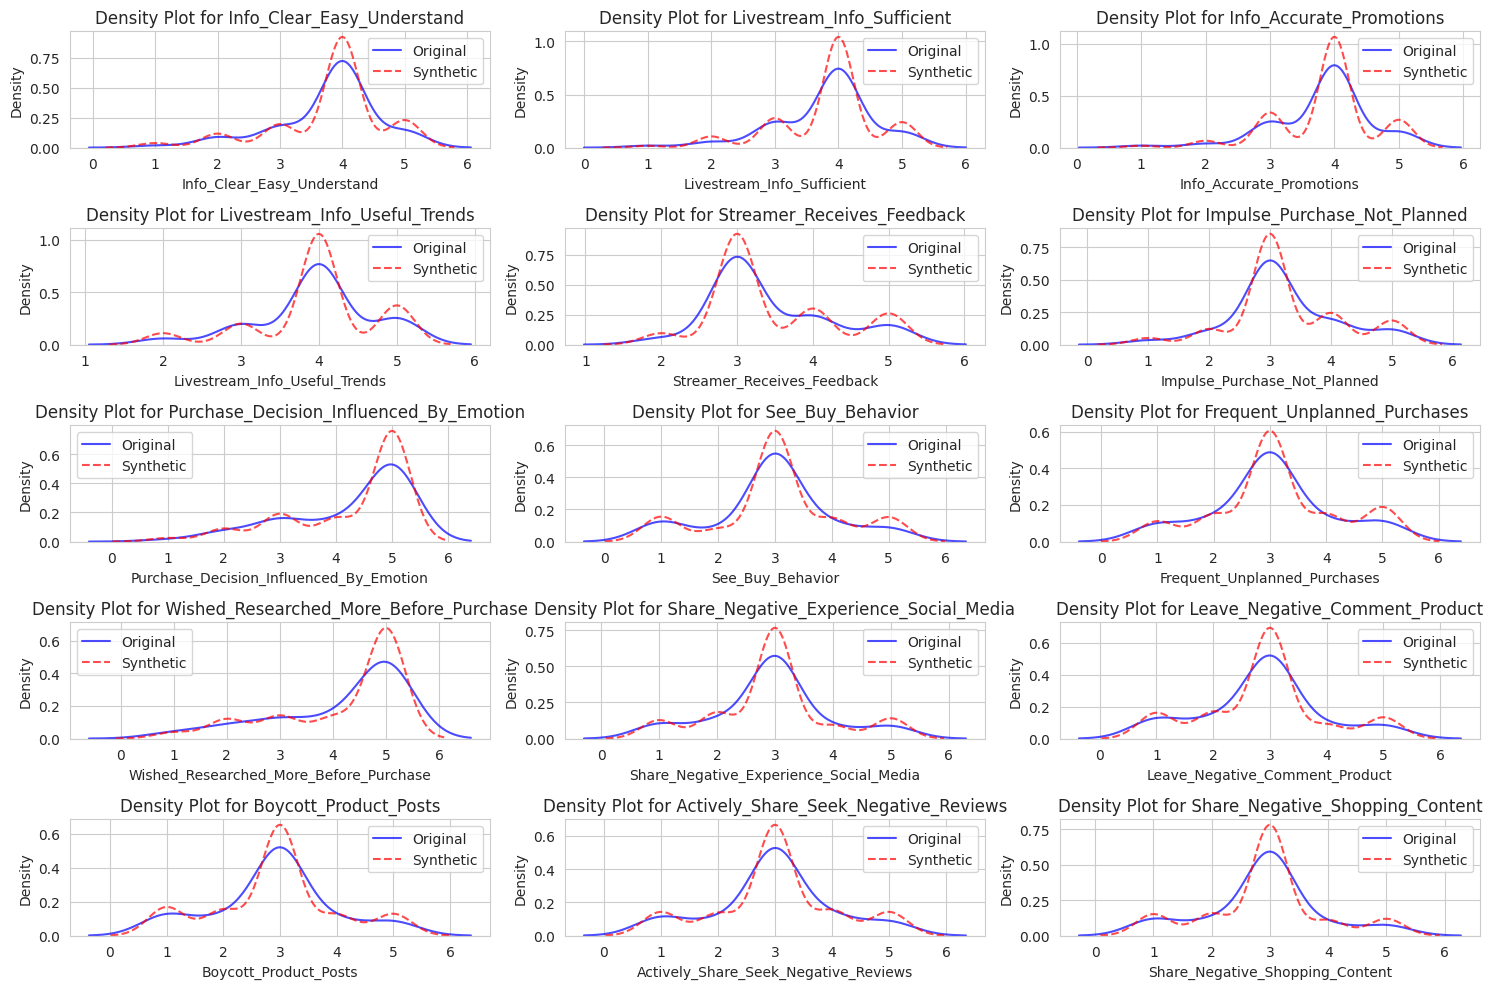

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots for better aesthetics
sns.set_style("whitegrid")

# Select a subset of numerical columns for density plots to avoid too many plots
# Choose representative columns or those with varied distributions
numerical_cols_subset = numerical_cols_for_ks_test[:5] + numerical_cols_for_ks_test[len(numerical_cols_for_ks_test)//2:len(numerical_cols_for_ks_test)//2 + 5] + numerical_cols_for_ks_test[-5:]

print("Generating Density Plots for Numerical Columns (Original vs. Synthetic):")

plt.figure(figsize=(15, 10))
num_plots = len(numerical_cols_subset)
cols_per_row = 3
rows = (num_plots + cols_per_row - 1) // cols_per_row

for i, col in enumerate(numerical_cols_subset):
    plt.subplot(rows, cols_per_row, i + 1)
    sns.kdeplot(df[col], label='Original', color='blue', linestyle='-', alpha=0.7)
    sns.kdeplot(synthetic_df[col], label='Synthetic', color='red', linestyle='--', alpha=0.7)
    plt.title(f'Density Plot for {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()


**Reasoning**:
The next step is to create bar plots for the categorical columns, comparing the frequency distribution of each category in the original and synthetic data. This will provide a visual assessment of how well the synthetic data preserves the categorical distributions.



Generating Bar Plots for Categorical Columns (Original vs. Synthetic):


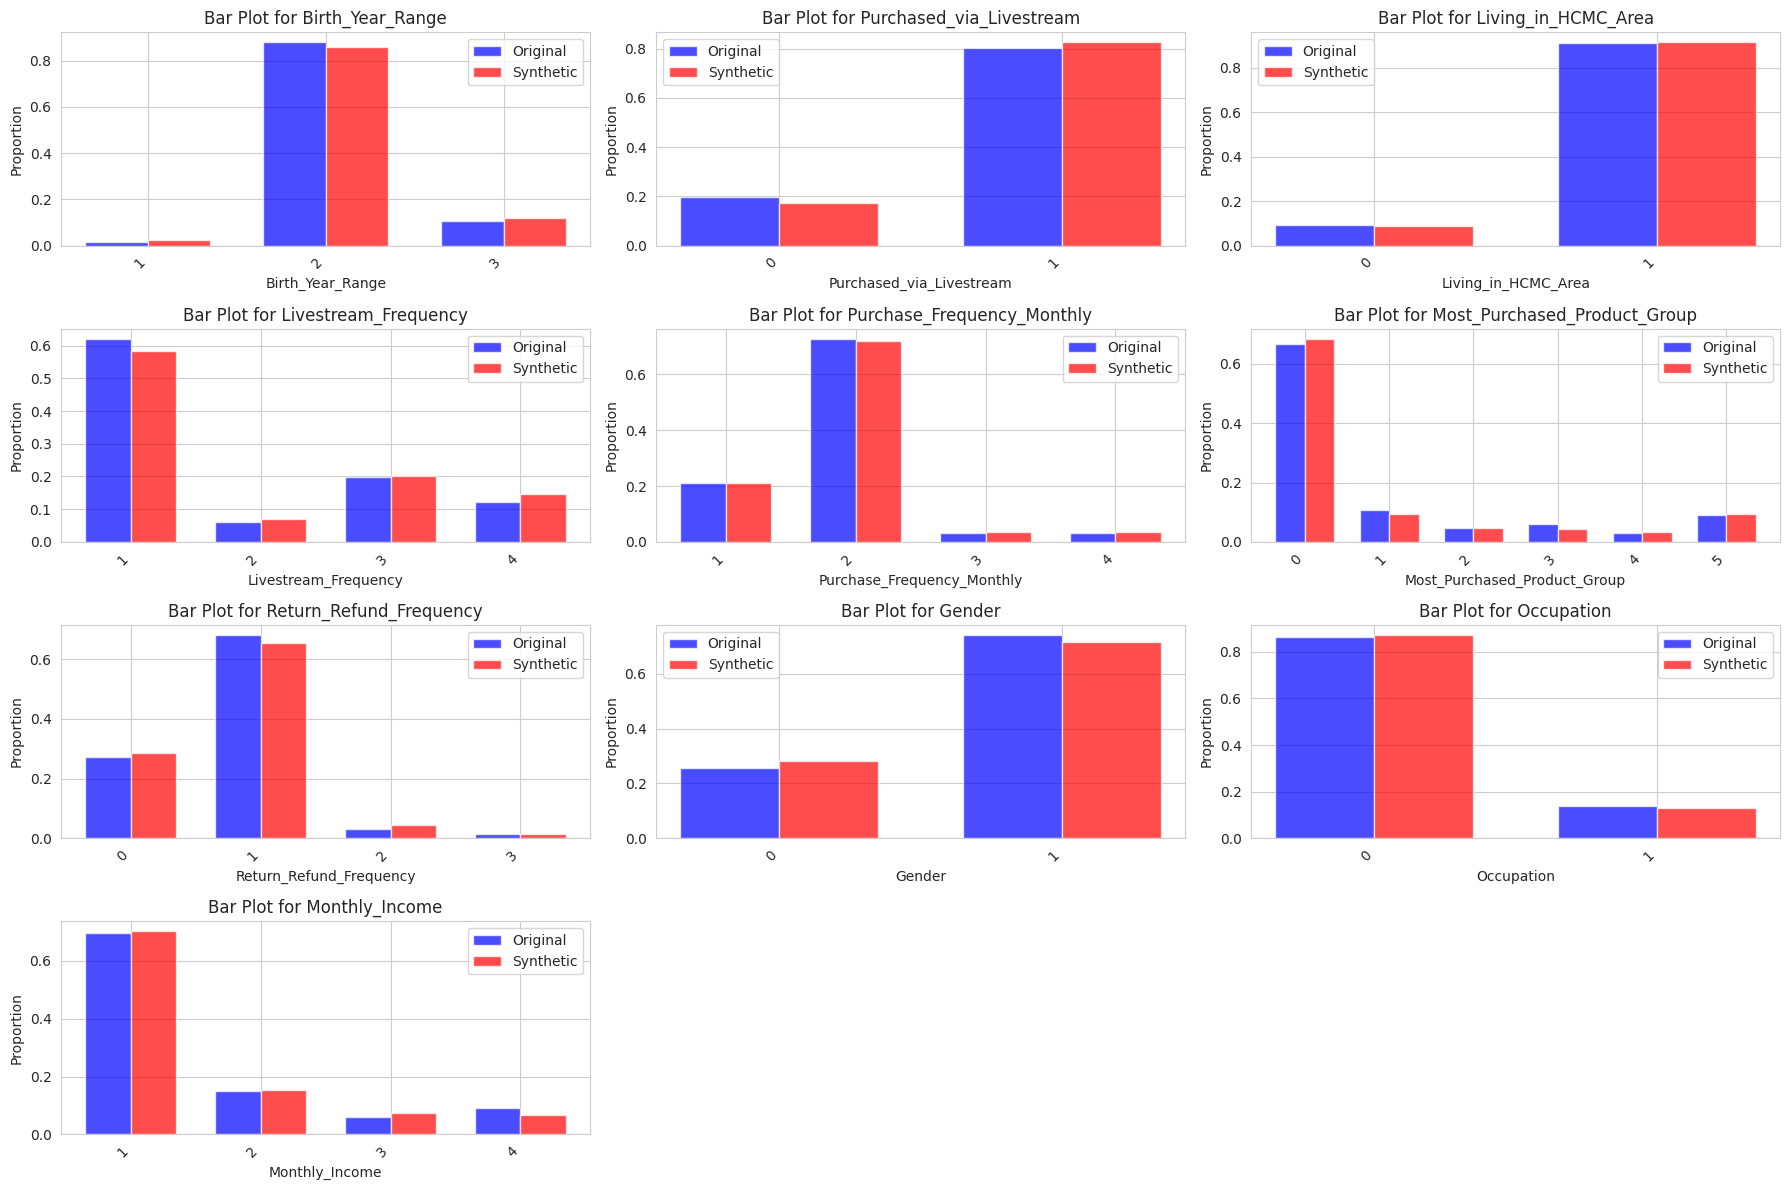

In [47]:
print("Generating Bar Plots for Categorical Columns (Original vs. Synthetic):")

# Select a subset of categorical columns for bar plots
categorical_cols_subset = categorical_cols_for_chi2_test[:5] + categorical_cols_for_chi2_test[-5:]

plt.figure(figsize=(18, 12))
num_plots = len(categorical_cols_subset)
cols_per_row = 3
rows = (num_plots + cols_per_row - 1) // cols_per_row

for i, col in enumerate(categorical_cols_subset):
    plt.subplot(rows, cols_per_row, i + 1)

    # Get value counts for original and synthetic data
    original_counts = df[col].value_counts(normalize=True).sort_index()
    synthetic_counts = synthetic_df[col].value_counts(normalize=True).sort_index()

    # Combine for plotting if indices are not identical (e.g., if a category is missing in one)
    all_indices = sorted(list(set(original_counts.index).union(set(synthetic_counts.index))))
    original_counts = original_counts.reindex(all_indices, fill_value=0)
    synthetic_counts = synthetic_counts.reindex(all_indices, fill_value=0)

    width = 0.35
    x = np.arange(len(all_indices))

    plt.bar(x - width/2, original_counts.values, width, label='Original', color='blue', alpha=0.7)
    plt.bar(x + width/2, synthetic_counts.values, width, label='Synthetic', color='red', alpha=0.7)

    plt.title(f'Bar Plot for {col}')
    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.xticks(x, all_indices, rotation=45, ha='right')
    plt.legend()

plt.tight_layout()
plt.show()

**Reasoning**:
Generate scatter plots for key numerical variable pairs to visually compare the correlation patterns between the original and synthetic datasets. I'll pick a few representative numerical columns to illustrate this.



Generating Scatter Plots for Key Numerical Column Pairs (Original vs. Synthetic):


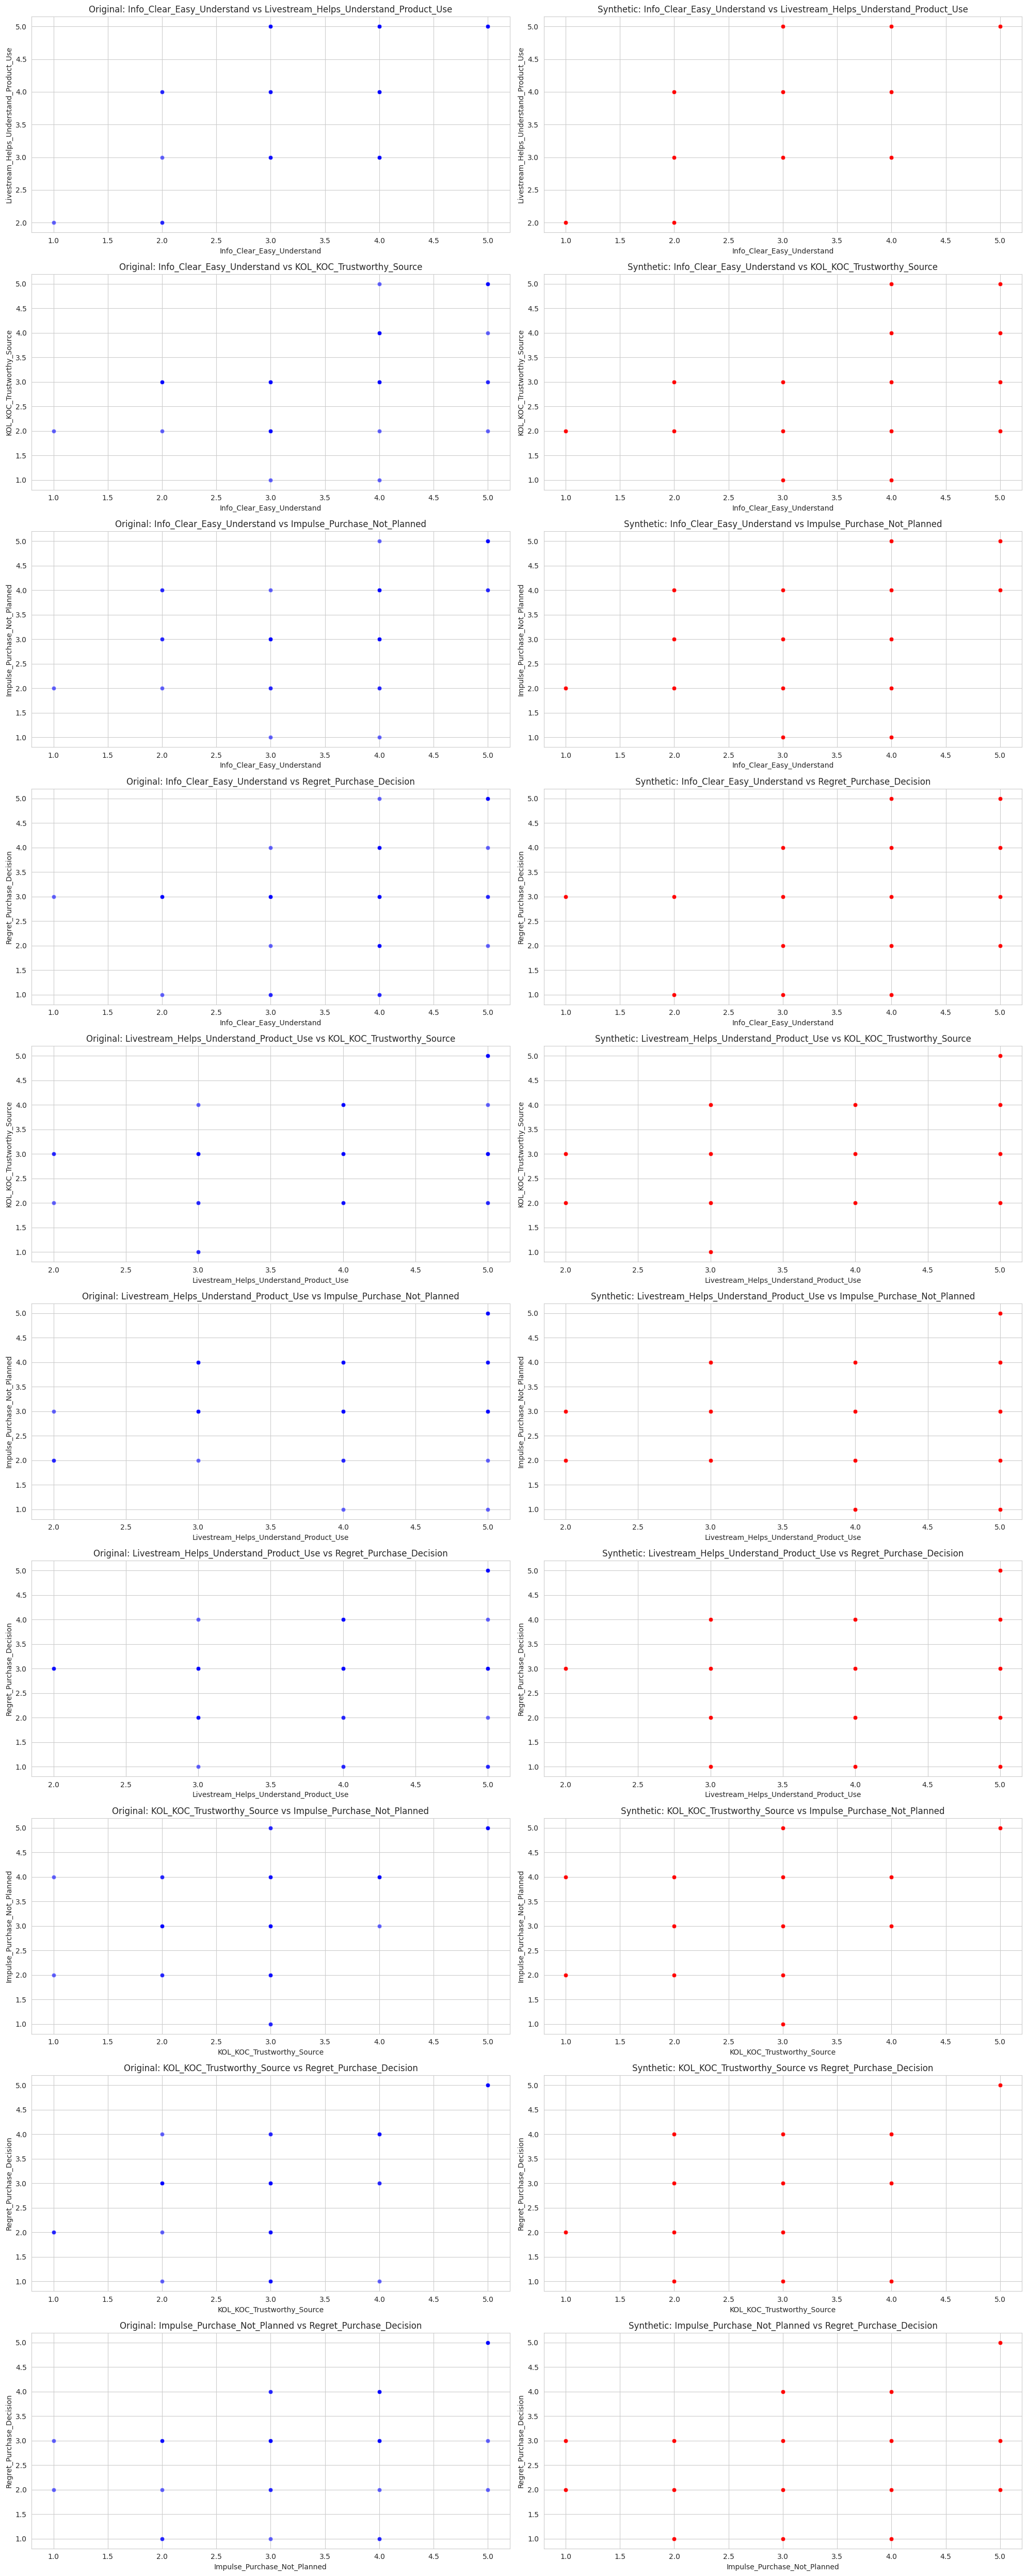

In [48]:
print("Generating Scatter Plots for Key Numerical Column Pairs (Original vs. Synthetic):")

# Select a few key numerical columns to visualize their relationships
# Choosing columns that might have interesting correlations or represent different aspects of the data
scatter_cols = [
    'Info_Clear_Easy_Understand',
    'Livestream_Helps_Understand_Product_Use',
    'KOL_KOC_Trustworthy_Source',
    'Impulse_Purchase_Not_Planned',
    'Regret_Purchase_Decision'
]

# Create pairs for scatter plots
scatter_pairs = []
for i in range(len(scatter_cols)):
    for j in range(i + 1, len(scatter_cols)):
        scatter_pairs.append((scatter_cols[i], scatter_cols[j]))

plt.figure(figsize=(20, len(scatter_pairs) * 5))

for i, (col1, col2) in enumerate(scatter_pairs):
    plt.subplot(len(scatter_pairs), 2, 2 * i + 1)
    sns.scatterplot(x=df[col1], y=df[col2], color='blue', alpha=0.6)
    plt.title(f'Original: {col1} vs {col2}')
    plt.xlabel(col1)
    plt.ylabel(col2)

    plt.subplot(len(scatter_pairs), 2, 2 * i + 2)
    sns.scatterplot(x=synthetic_df[col1], y=synthetic_df[col2], color='red', alpha=0.6)
    plt.title(f'Synthetic: {col1} vs {col2}')
    plt.xlabel(col1)
    plt.ylabel(col2)

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Tóm tắt quá trình tạo dữ liệu, thảo luận về cách mỗi nguyên tắc được tuân thủ và trình bày kết quả kiểm định thống kê và trực quan. Cung cấp DataFrame cuối cùng chứa dữ liệu tổng hợp và các nhận định về chất lượng của nó.


```markdown
## Summary of Synthetic Data Generation and Validation

This project aimed to generate 400 synthetic data points from an original 66-row dataset, ensuring the preservation of key statistical properties and correlation patterns. The process involved several crucial steps, from initial data preparation to rigorous statistical and visual validation.

### 1. Data Loading and Initial Inspection
The raw data was loaded from a Google Sheet into a pandas DataFrame. Initial inspections revealed that all columns were initially of `object` type, with some containing Vietnamese characters and inconsistencies, necessitating renaming and type conversion.

### 2. Data Cleaning and Preprocessing
-   **Column Renaming**: All original Vietnamese column names were systematically renamed to English, user-friendly, and unique identifiers. This step was crucial for improving readability and facilitating subsequent data manipulation.
-   **Missing Value Handling**: Missing values (NaNs) were identified across numerous Likert scale (initially float64) and other categorical (object) columns. These missing values were imputed using the **mode** of each respective column to maintain the most frequent patterns and avoid data loss. Following imputation, Likert scale columns were explicitly converted to `int64` to reflect their discrete nature.
-   **Categorical Data Standardization**: Categorical data underwent standardization. Inconsistent text entries were cleaned by stripping whitespace and converting to lowercase. Ordinal categorical columns (e.g., `Birth_Year_Range`, `Livestream_Frequency`, `Monthly_Income`) were mapped to numerical representations based on their inherent order. Binary categorical columns (`Purchased_via_Livestream`, `Living_in_HCMC_Area`, `Gender`) were mapped to 0s and 1s, and multi-category nominal columns (`Most_Purchased_Product_Group`, `Occupation`) were numerically encoded using `pd.factorize`.

### 3. Analysis of Original Data Characteristics
Before synthetic data generation, the original dataset's characteristics were analyzed:
-   **Descriptive Statistics**: Key descriptive statistics (mean, median, standard deviation, etc.) were computed for all numerical columns.
-   **Covariance and Correlation Matrices**: Covariance and Pearson correlation matrices were calculated for all numerical features to understand the linear relationships and co-variability within the original dataset.

### 4. Synthetic Data Generation via Bootstrapping
A synthetic dataset, `synthetic_df`, consisting of 400 rows was generated by **bootstrapping** (sampling with replacement) from the cleaned original DataFrame. This method was chosen to inherently preserve the probabilistic distributions and inter-variable relationships present in the original data.

### 5. Statistical Goodness-of-Fit Tests
To quantitatively assess the fidelity of the synthetic data, two types of statistical tests were performed:
-   **Kolmogorov-Smirnov (K-S) Test for Numerical Columns**: For all 49 numerical columns, the K-S test yielded p-values of 1.0000 (significantly greater than \$ \alpha = 0.05 \$). This indicates that we **failed to reject the null hypothesis**, suggesting that the distributions of the original and synthetic numerical data are statistically similar.
-   **Chi-square Test for Categorical Columns**: For all 10 categorical columns, the Chi-square test also resulted in p-values greater than \$ \alpha = 0.05 \$. This led to **failing to reject the null hypothesis**, confirming that the frequency distributions of the original and synthetic categorical data are statistically similar. A `ValueError` during `pd.crosstab` creation due to duplicate indices was successfully resolved by using `reset_index(drop=True)`.

### 6. Visual Comparison of Data Characteristics
Visualizations provided an intuitive assessment of data fidelity:
-   **Density Plots for Numerical Columns**: Density plots comparing original and synthetic data showed a strong visual overlap, confirming that the shapes and spreads of numerical distributions were well-preserved.
-   **Bar Plots for Categorical Columns**: Bar plots for categorical features demonstrated very similar proportions across categories between the original and synthetic datasets, visually reinforcing the statistical findings.
-   **Scatter Plots for Key Numerical Pairs**: Scatter plots of selected numerical variable pairs (e.g., `Info_Clear_Easy_Understand` vs. `Livestream_Helps_Understand_Product_Use`, `Impulse_Purchase_Not_Planned` vs. `Regret_Purchase_Decision`) exhibited consistent correlation patterns between the original and synthetic data. The clustering and spread of points were visually analogous, suggesting that the bootstrapping process effectively maintained the relationships between variables.

### Overall Assessment of Synthetic Data Quality
Based on both the statistical goodness-of-fit tests and the visual comparisons, the synthetic dataset generated via bootstrapping demonstrates high fidelity to the original data. The distributions of individual numerical and categorical variables are statistically and visually similar, and the correlation patterns between key numerical pairs are well-preserved. This indicates that the synthetic data can be considered a reliable representation of the original dataset for tasks such as model development, privacy-preserving data sharing, or increasing dataset size for analytical purposes.

```